<a href="https://colab.research.google.com/github/sidneyhendrzak/course-grade-distribution-regression/blob/main/MATH637_FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MATH637 - Mathematical Techniques in Data Science
#Final Project Code - Predicting Final University Course Grades & Distribution

####Jacob Meredith
####Madison Johnson
####Sidney Hendrzak
####Joshua LaFrance

In [ ]:
from re import X
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, classification_report, mean_absolute_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.svm import SVC, LinearSVR, SVR
from sklearn.ensemble import RandomForestClassifier, VotingRegressor, BaggingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso, LogisticRegression, LinearRegression, ElasticNet
from scipy.stats import linregress
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
import random
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import hamming_loss

# REGRESSION MODELS FUNCTION DEFINITION

In [ ]:
"""
REGRESSION FUNCTION DEFINITION - MUST RUN BEFORE CALLING REGRESSION CODE BLOCKS
"""
def run_regression_models(X_data, Y_data, print_outputs = False, show_error = True, data_is_pandas = True, labels = ["F", "D", "C", "B", "A"], y_max = 100, seed = 42, seed_eval = False, run_lin = False, run_ridge = False, run_lasso = False, run_enet = False, run_dec_tree = False, run_rf = False, run_knn = False, run_all = True, print_graphs = True):
  if data_is_pandas:
    # Convert data to numpy array and remove last "TEST" row
    X_data = pd.DataFrame.to_numpy(X_data)
    Y_data = pd.DataFrame.to_numpy(Y_data)
    X_data = X_data[0:len(X_data)-1]
    Y_data = Y_data[0:len(Y_data)-1]
  X_data = X_data.astype(np.float64)
  Y_data = Y_data.astype(np.float64)

  if run_all:
    run_lin = True
    run_ridge = True
    run_lasso = True
    run_enet = True
    run_dec_tree = True
    run_rf = True
    run_knn = True

  mae_dict = {}
  # Create train and test data
  X_train, X_test, Y_train, Y_test = train_test_split(X_data, Y_data, test_size=0.2, random_state = seed)

  #print(X_train)
  #print(Y_train)

  # SCALE THE DATA:
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)
  Y_train_scaled = scaler.fit_transform(Y_train)
  Y_test_scaled = scaler.transform(Y_test)

  random_index = random.randint(0, 19)
  best_mae = 1000000000000000

  # -----------------------------------------------------------------------------------------------------
  # LINEAR REGRESSION:
  if run_lin:
    # Create model
    lin_model = LinearRegression()

    # Train model:
    lin_model.fit(X_train_scaled, Y_train_scaled)

    # Predict distribution
    Y_pred_scaled = lin_model.predict(X_test_scaled)

    # Inverse scale predictions
    Y_pred = scaler.inverse_transform(Y_pred_scaled)

    Y_pred = np.maximum(0, Y_pred)
    Y_pred = (Y_pred.T / np.sum(Y_pred, axis=1)).T * 100

    if mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average') < best_mae:
      best_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')
      best_Y_pred = Y_pred

    mae_dict.update({(mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')): "Linear Regression"})
    lin_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')

    if print_outputs:
      print(Y_pred)
      print(Y_test)
    if show_error:
      print(f"LINEAR REGRESSION RESULTS:")
      graph_distributions(Y_pred[random_index], Y_test[random_index], "Linear Regression", labels, y_max)
      print(f"Mean Squared Error: {mean_squared_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Mean Absolute Error: {mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Custom Error: {custom_error(Y_test, Y_pred)}")
      print(f"R2 Score: {r2_score(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"---------------------------")

  # -----------------------------------------------------------------------------------------------------
  # RIDGE REGRESSION:
  if run_ridge:
    pipeline = Pipeline([
        ('poly', PolynomialFeatures()),
        ('ridge', Ridge())
    ])

    params = {
        'poly__degree': [1, 2, 3],
        'ridge__alpha': np.logspace(-3, 3, 10),
        'ridge__solver': ['auto']
    }
    ridge_regressor = GridSearchCV(pipeline, params, scoring='neg_mean_absolute_error', cv=5, n_jobs=-1)
    ridge_regressor.fit(X_train_scaled, Y_train_scaled)
    Y_pred_scaled = ridge_regressor.predict(X_test_scaled)
    Y_pred = scaler.inverse_transform(Y_pred_scaled)

    Y_pred = np.maximum(0, Y_pred)
    Y_pred = (Y_pred.T / np.sum(Y_pred, axis=1)).T * 100

    if mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average') < best_mae:
      best_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')
      best_Y_pred = Y_pred

    mae_dict.update({(mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')): "Ridge Regression"})
    ridge_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')

    if print_outputs:
      print(Y_pred)
      print(Y_test)
    if show_error:
      print(f"RIDGE REGRESSION RESULTS:")
      graph_distributions(Y_pred[random_index], Y_test[random_index], "Ridge Regression", labels, y_max)
      print(f"Mean Squared Error: {mean_squared_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Mean Absolute Error: {mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Custom Error: {custom_error(Y_test, Y_pred)}")
      print(f"R2 score: {r2_score(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"---------------------------")
  # -----------------------------------------------------------------------------------------------------
  # LASSO REGRESSION:
  if run_lasso:
    params = {
        'alpha': np.logspace(-3, 3, 10)
    }
    lasso_regressor = GridSearchCV(Lasso(max_iter=10000), params, scoring='neg_mean_absolute_error', cv=5)
    lasso_regressor.fit(X_train_scaled, Y_train_scaled)
    Y_pred_scaled = lasso_regressor.predict(X_test_scaled)
    Y_pred = scaler.inverse_transform(Y_pred_scaled)

    Y_pred = np.maximum(0, Y_pred)
    Y_pred = (Y_pred.T / np.sum(Y_pred, axis=1)).T * 100

    if mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average') < best_mae:
      best_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')
      best_Y_pred = Y_pred

    mae_dict.update({(mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')): "Lasso Regression"})
    lasso_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')

    if print_outputs:
      print(Y_pred)
      print(Y_test)
    if show_error:
      print(f"LASSO REGRESSION RESULTS:")
      graph_distributions(Y_pred[random_index], Y_test[random_index], "Lasso Regression", labels, y_max)
      print(f"Mean Squared Error: {mean_squared_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Mean Absolute Error: {mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Custom Error: {custom_error(Y_test, Y_pred)}")
      print(f"R2 score: {r2_score(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"---------------------------")
  # -----------------------------------------------------------------------------------------------------
  # ELASTIC NET REGRESSION:
  if run_enet:
    params = {
        'alpha': np.logspace(-3, 3, 10),
        'l1_ratio': np.linspace(0.1, 0.9, 10)
    }
    elastic_net_regressor = GridSearchCV(ElasticNet(max_iter=50000), params, scoring='neg_mean_absolute_error', cv=5)
    elastic_net_regressor.fit(X_train_scaled, Y_train_scaled)
    Y_pred_scaled = elastic_net_regressor.predict(X_test_scaled)
    Y_pred = scaler.inverse_transform(Y_pred_scaled)

    Y_pred = np.maximum(0, Y_pred)
    Y_pred = (Y_pred.T / np.sum(Y_pred, axis=1)).T * 100

    if mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average') < best_mae:
      best_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')
      best_Y_pred = Y_pred

    mae_dict.update({(mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')): "Elastic Net Regression"})
    enet_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')

    if print_outputs:
      print(Y_pred)
      print(Y_test)
    if show_error:
      print(f"ELASTIC NET REGRESSION RESULTS:")
      graph_distributions(Y_pred[random_index], Y_test[random_index], "Elastic Net Regression", labels, y_max)
      print(f"Mean Squared Error: {mean_squared_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Mean Absolute Error: {mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Custom Error: {custom_error(Y_test, Y_pred)}")
      print(f"R2 score: {r2_score(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"---------------------------")
  # -----------------------------------------------------------------------------------------------------
  # DECISION TREE REGRESSION:
  if run_dec_tree:
    params = {
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'ccp_alpha': np.logspace(-3, 3, 10)
    }

    dect_tree_regressor = GridSearchCV(DecisionTreeRegressor(random_state=42), params, scoring='neg_mean_absolute_error', cv=5)
    dect_tree_regressor.fit(X_train_scaled, Y_train_scaled)
    Y_pred_scaled = dect_tree_regressor.predict(X_test_scaled)
    Y_pred = scaler.inverse_transform(Y_pred_scaled)

    Y_pred = np.maximum(0, Y_pred)
    Y_pred = (Y_pred.T / np.sum(Y_pred, axis=1)).T * 100

    if mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average') < best_mae:
      best_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')
      best_Y_pred = Y_pred

    mae_dict.update({(mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')): "Decision Tree Regression"})
    dec_tree_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')

    if print_outputs:
      print(Y_pred)
      print(Y_test)
    if show_error:
      print(f"DECISION TREE REGRESSION RESULTS:")
      graph_distributions(Y_pred[random_index], Y_test[random_index], "Decision Tree Regression", labels, y_max)
      print(f"Mean Squared Error: {mean_squared_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Mean Absolute Error: {mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Custom Error: {custom_error(Y_test, Y_pred)}")
      print(f"R2 score: {r2_score(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"---------------------------")
  # -----------------------------------------------------------------------------------------------------
  # RANDOM FOREST REGRESSION:
  if run_rf:
    params = {
        'n_estimators': [50, 100],
        'max_depth': [None, 10, 20],
        'min_samples_split': [5, 10],
        'min_samples_leaf': [1, 2]
    }
    rf_regressor = GridSearchCV(RandomForestRegressor(random_state=42), params, scoring='neg_mean_absolute_error', cv=5)
    rf_regressor.fit(X_train_scaled, Y_train_scaled)
    Y_pred_scaled = rf_regressor.predict(X_test_scaled)
    Y_pred = scaler.inverse_transform(Y_pred_scaled)

    Y_pred = np.maximum(0, Y_pred)
    Y_pred = (Y_pred.T / np.sum(Y_pred, axis=1)).T * 100

    if mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average') < best_mae:
      best_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')
      best_Y_pred = Y_pred

    mae_dict.update({(mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')): "Random Forest Regression"})
    rf_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')

    if print_outputs:
      print(Y_pred)
      print(Y_test)
    if show_error:
      print(f"RANDOM FOREST REGRESSION RESULTS:")
      graph_distributions(Y_pred[random_index], Y_test[random_index], "Random Forest Regression", labels, y_max)
      print(f"Mean Squared Error: {mean_squared_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Mean Absolute Error: {mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Custom Error: {custom_error(Y_test, Y_pred)}")
      print(f"R2 score: {r2_score(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"---------------------------")

  # -----------------------------------------------------------------------------------------------------
  # KNEIGHBORS REGRESSION:
  if run_knn:
    params_knn = {
        'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    }
    knn_regressor = GridSearchCV(KNeighborsRegressor(), params_knn, scoring='neg_mean_absolute_error', cv=5, n_jobs=-1)
    knn_regressor.fit(X_train_scaled, Y_train_scaled)
    Y_pred_scaled = knn_regressor.predict(X_test_scaled)
    Y_pred = scaler.inverse_transform(Y_pred_scaled)

    if mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average') < best_mae:
      best_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')
      best_Y_pred = Y_pred

    mae_dict.update({(mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')): "KNeighbors Regression"})
    knn_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')

    if print_outputs:
      print(Y_pred)
      print(Y_test)
    if show_error:
      print(f"KNEIGHBORS REGRESSION RESULTS:")
      graph_distributions(Y_pred[random_index], Y_test[random_index], "KNeighbors Regression", labels, y_max)
      print(f"Mean Squared Error: {mean_squared_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Mean Absolute Error: {mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Custom Error: {custom_error(Y_test, Y_pred)}")
      print(f"R2 Score: {r2_score(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"---------------------------")

  if print_graphs:
    for i in range(3):
      random_final_index = random.randint(0, 19)
      graph_distributions(best_Y_pred[random_final_index], Y_test[random_final_index], f'{mae_dict[best_mae]}', labels, y_max)

  if(seed_eval):
    return lin_mae, ridge_mae, lasso_mae, enet_mae, dec_tree_mae, rf_mae, knn_mae, mae_dict
  else:
    return mae_dict

# -----------------------------------------------------------------------------------------------------
# CUSTOM ERROR CALCULATION
def custom_error(y_true, y_pred, threshold = 5):
  error = 0
  y_true = y_true.astype(np.float64)
  for i in range(len(y_true)):
    for j in range(len(y_true[i])):
      if abs(y_true[i][j] - y_pred[i][j]) > threshold:
        error += 1
  return error/(5*len(y_true))

# -----------------------------------------------------------------------------------------------------
# Histogram Code

def graph_distributions(Y_pred, Y_test, model_type, labels, y_max):
  x = np.arange(len(labels))
  width = 0.35
  plt.bar(x - width/2, Y_pred, width, label='Predicted')
  plt.bar(x + width/2, Y_test, width, label='True')
  plt.xticks(x, labels)
  plt.ylabel("Percentage of Students (%)")
  plt.ylim(0, y_max)
  plt.title(f'Predicted vs True Values - {model_type}')
  plt.legend()
  plt.show()

# -----------------------------------------------------------------------------------------------------

# GRADE DISTRIBUTION MODELS: BEST & MOST CONSISTENT MODELS PER DATASET

In [ ]:
"""
GRADE DISTRIBUTION MODELS - FIND ABSOLUTE BEST & MOST CONSISTENT MODEL ACCROSS MULTIPLE SEEDS
"""
import warnings
warnings.filterwarnings("ignore")

model_dict = {}

def evaluate_consistancy(X_data, Y_data):
  lin_mae_arr = []
  ridge_mae_arr = []
  lasso_mae_arr = []
  enet_mae_arr = []
  dec_tree_mae_arr = []
  rf_mae_arr = []
  knn_mae_arr = []
  seed_arr = []

  for i in range(22, 44, 2):
    lin_mae, ridge_mae, lasso_mae, enet_mae, dec_tree_mae, rf_mae, knn_mae, mae_dict1 = run_regression_models(X_data, Y_data, show_error = False, seed = i, seed_eval = True, print_graphs = False)
    lin_mae_arr.append(lin_mae)
    ridge_mae_arr.append(ridge_mae)
    lasso_mae_arr.append(lasso_mae)
    enet_mae_arr.append(enet_mae)
    dec_tree_mae_arr.append(dec_tree_mae)
    rf_mae_arr.append(rf_mae)
    knn_mae_arr.append(knn_mae)
    seed_arr.append(i)

  lin_mae_avg = np.mean(lin_mae_arr)
  ridge_mae_avg = np.mean(ridge_mae_arr)
  lasso_mae_avg = np.mean(lasso_mae_arr)
  enet_mae_avg = np.mean(enet_mae_arr)
  dec_tree_mae_avg = np.mean(dec_tree_mae_arr)
  rf_mae_avg = np.mean(rf_mae_arr)
  knn_mae_avg = np.mean(knn_mae_arr)

  avg_mae_dict = {lin_mae_avg: "Linear Regression", ridge_mae_avg: "Ridge Regression", lasso_mae_avg: "Lasso Regression", enet_mae_avg: "Elastic Net Regression", dec_tree_mae_avg: "Decision Tree Regression", rf_mae_avg: "Random Forest Regression", knn_mae_avg: "KNeighbors Regression"}
  best_mae_avg = min(avg_mae_dict)
  best_mae_model = avg_mae_dict[best_mae_avg]
  return best_mae_model, best_mae_avg, seed_arr
# -----------------------------------------------------------------------------------------------------
# MODEL 1: ALL PARAMETERS
X_data = pd.read_csv('Final Datasheet - XDataImport.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - DISTRIBUTION.csv')

print("MODEL 1: ALL PARAMETERS")
best_mae_model, best_mae_avg, seed_arr = evaluate_consistancy(X_data, Y_data)
print(f'Best & Most Consistent Model w/ Average MAE Score Across {len(seed_arr)} Random Seeds: {best_mae_model}: {best_mae_avg}')

print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 2: NO QUIZ OR MISC
X_data = pd.read_csv('Final Datasheet - XDataImport - NO QUIZ OR MISC.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - DISTRIBUTION.csv')

print("MODEL 2: NO QUIZ OR MISC")
best_mae_model, best_mae_avg, seed_arr = evaluate_consistancy(X_data, Y_data)
print(f'Best & Most Consistent Model w/ Average MAE Score Across {len(seed_arr)} Random Seeds: {best_mae_model}: {best_mae_avg}')
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 3: EXAMS & HW ONLY
X_data = pd.read_csv('Final Datasheet - XDataImport - EXAMS & HW ONLY.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - DISTRIBUTION.csv')

print("MODEL 3: EXAMS & HW ONLY")
best_mae_model, best_mae_avg, seed_arr = evaluate_consistancy(X_data, Y_data)
print(f'Best & Most Consistent Model w/ Average MAE Score Across {len(seed_arr)} Random Seeds: {best_mae_model}: {best_mae_avg}')
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 4: EXAMS (COMBINED) & HW ONLY
X_data = pd.read_csv('Final Datasheet - XDataImport - EXAMS (COMBINED) & HW ONLY.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - DISTRIBUTION.csv')

print("MODEL 4: EXAMS (COMBINED) & HW ONLY")
best_mae_model, best_mae_avg, seed_arr = evaluate_consistancy(X_data, Y_data)
print(f'Best & Most Consistent Model w/ Average MAE Score Across {len(seed_arr)} Random Seeds: {best_mae_model}: {best_mae_avg}')
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 5: WEIGHTS ONLY
X_data = pd.read_csv('Final Datasheet - XDataImport - WEIGHTS ONLY.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - DISTRIBUTION.csv')

print("MODEL 5: WEIGHTS ONLY")
best_mae_model, best_mae_avg, seed_arr = evaluate_consistancy(X_data, Y_data)
print(f'Best & Most Consistent Model w/ Average MAE Score Across {len(seed_arr)} Random Seeds: {best_mae_model}: {best_mae_avg}')
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------



MODEL 1: ALL PARAMETERS
Best & Most Consistent Model w/ Average MAE Score Across 11 Random Seeds: Elastic Net Regression: 7.2713459141882515
#######################################################################
MODEL 2: NO QUIZ OR MISC
Best & Most Consistent Model w/ Average MAE Score Across 11 Random Seeds: Elastic Net Regression: 7.2046066141418414
#######################################################################
MODEL 3: EXAMS & HW ONLY
Best & Most Consistent Model w/ Average MAE Score Across 11 Random Seeds: Linear Regression: 7.235404773313365
#######################################################################
MODEL 4: EXAMS (COMBINED) & HW ONLY
Best & Most Consistent Model w/ Average MAE Score Across 11 Random Seeds: Elastic Net Regression: 7.202887432755353
#######################################################################
MODEL 5: WEIGHTS ONLY
Best & Most Consistent Model w/ Average MAE Score Across 11 Random Seeds: Elastic Net Regression: 7.240084786077616
###

# GRADE DISTRIBUTION MODELS - CASE BY CASE BASIS

MODEL 1: ALL PARAMETERS


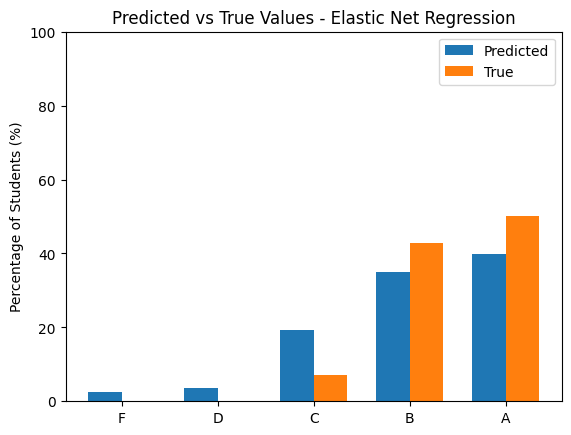

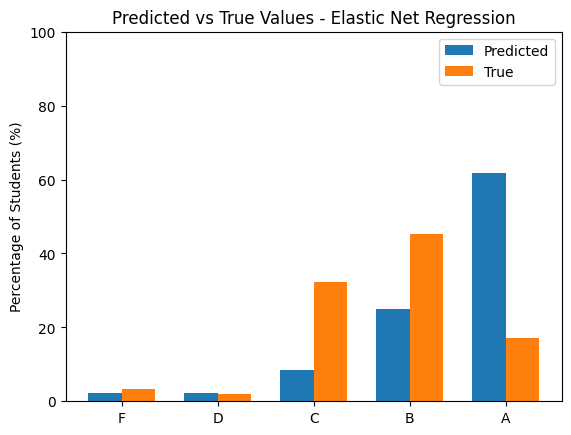

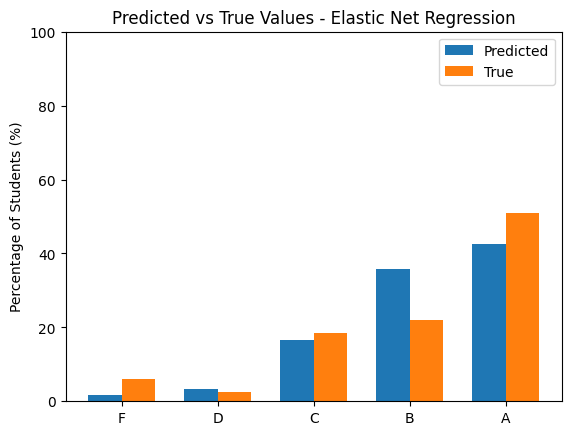

{7.570672995879399: 'Elastic Net Regression'}
Best Model and associated MAE Score: Elastic Net Regression: 7.570672995879399
#######################################################################
MODEL 2: NO QUIZ OR MISC


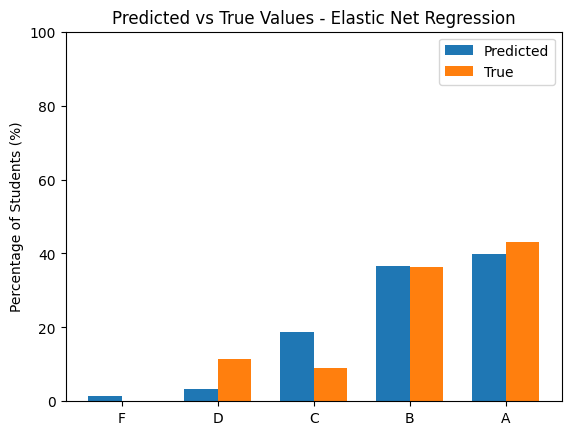

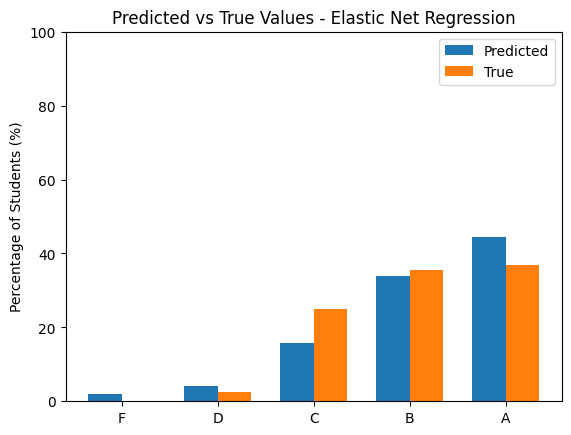

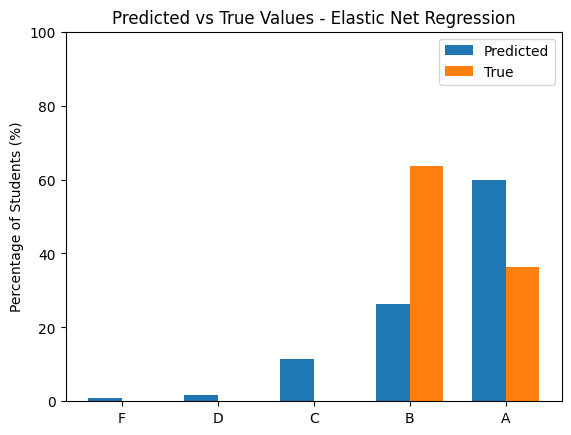

{7.592783642642739: 'Elastic Net Regression'}
Best Model and associated MAE Score: Elastic Net Regression: 7.592783642642739
#######################################################################
MODEL 3: EXAMS & HW ONLY


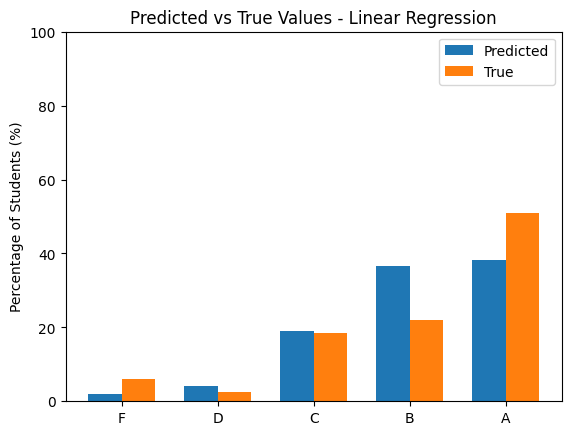

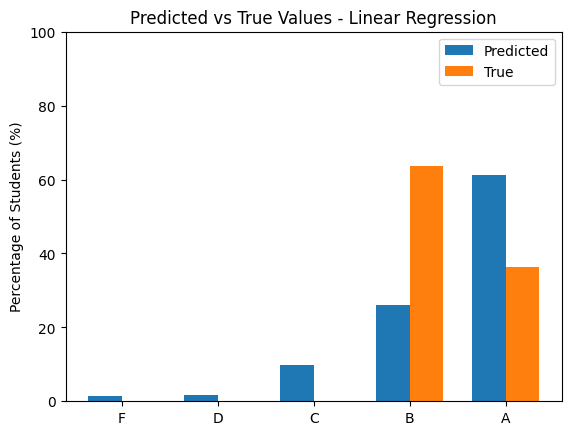

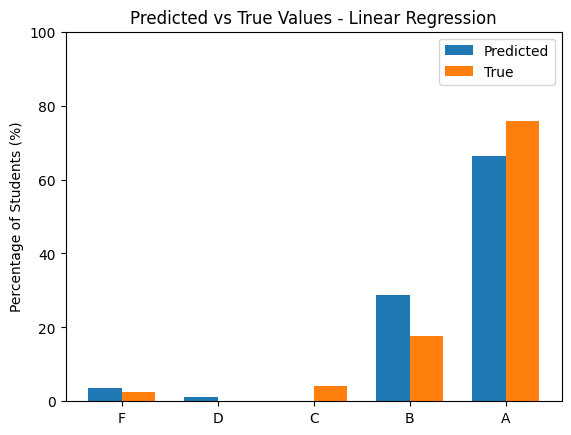

{7.604619308453513: 'Linear Regression'}
Best Model and associated MAE Score: Linear Regression: 7.604619308453513
#######################################################################
MODEL 4: EXAMS (COMBINED) & HW ONLY


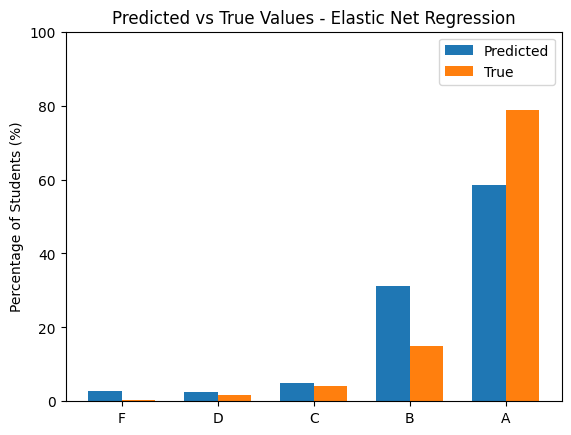

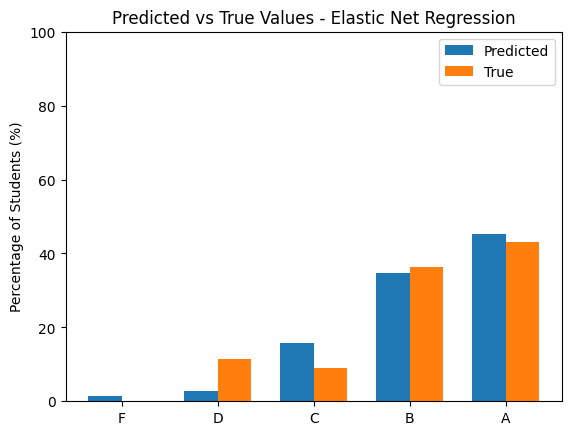

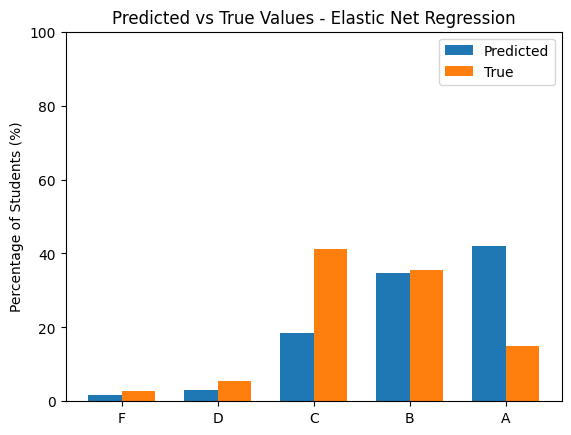

{7.628645778995154: 'Elastic Net Regression'}
Best Model and associated MAE Score: Elastic Net Regression: 7.628645778995154
#######################################################################
MODEL 5: WEIGHTS ONLY


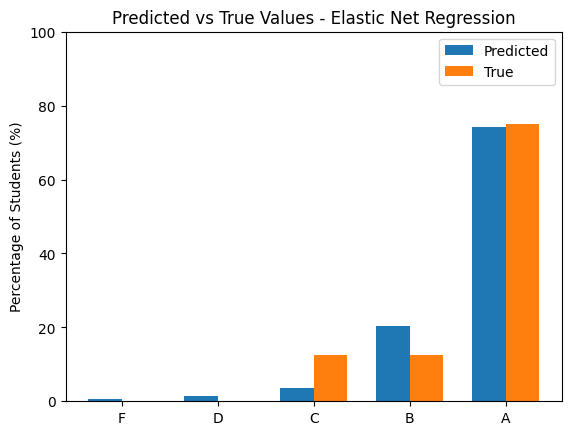

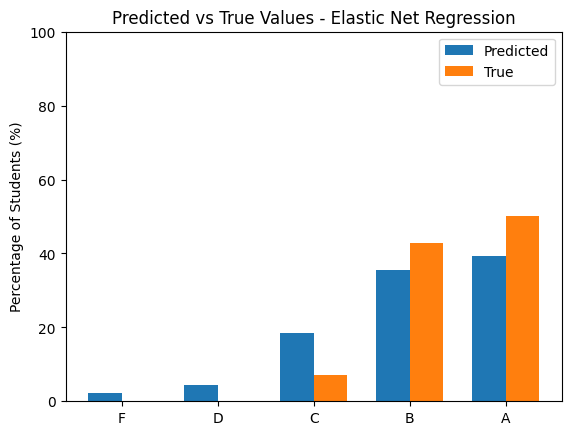

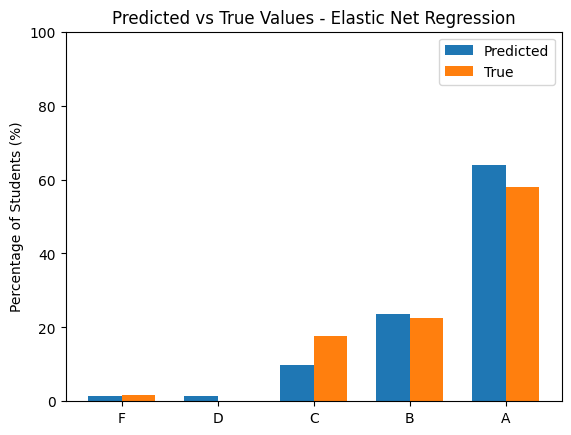

{7.525959008078663: 'Elastic Net Regression'}
Best Model and associated MAE Score: Elastic Net Regression: 7.525959008078663
#######################################################################
FINAL RESULTS:
Best OVERALL Model and Data Grouping with associated MAE Score: Elastic Net Regression - MODEL 5: WEIGHTS ONLY: 7.525959008078663


In [ ]:
"""
GRADE DISTRIBUTION MODELS
"""
import warnings
warnings.filterwarnings("ignore")

model_dict = {}
# -----------------------------------------------------------------------------------------------------
# MODEL 1: ALL PARAMETERS
X_data = pd.read_csv('Final Datasheet - XDataImport.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - DISTRIBUTION.csv')

print("MODEL 1: ALL PARAMETERS")
mae_dict1 = run_regression_models(X_data, Y_data, show_error = False, run_all = False, run_enet = True)
print(mae_dict1)
best_mae = min(mae_dict1)
print(f'Best Model and associated MAE Score: {mae_dict1[best_mae]}: {best_mae}')
model_dict.update({best_mae: f'{mae_dict1[best_mae]} - MODEL 1: ALL PARAMETERS'})
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 2: NO QUIZ OR MISC
X_data = pd.read_csv('Final Datasheet - XDataImport - NO QUIZ OR MISC.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - DISTRIBUTION.csv')

print("MODEL 2: NO QUIZ OR MISC")
mae_dict2 = run_regression_models(X_data, Y_data, show_error = False, run_all = False, run_enet = True)
print(mae_dict2)
best_mae = min(mae_dict2)
print(f'Best Model and associated MAE Score: {mae_dict2[best_mae]}: {best_mae}')
model_dict.update({best_mae: f'{mae_dict2[best_mae]} - MODEL 2: NO QUIZ OR MISC'})
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 3: EXAMS & HW ONLY
X_data = pd.read_csv('Final Datasheet - XDataImport - EXAMS & HW ONLY.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - DISTRIBUTION.csv')

print("MODEL 3: EXAMS & HW ONLY")
mae_dict3 = run_regression_models(X_data, Y_data, show_error = False, run_all = False, run_lin = True)
print(mae_dict3)
best_mae = min(mae_dict3)
print(f'Best Model and associated MAE Score: {mae_dict3[best_mae]}: {best_mae}')
model_dict.update({best_mae: f'{mae_dict3[best_mae]} - MODEL 3: EXAMS & HW ONLY'})
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 4: EXAMS (COMBINED) & HW ONLY
X_data = pd.read_csv('Final Datasheet - XDataImport - EXAMS (COMBINED) & HW ONLY.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - DISTRIBUTION.csv')

print("MODEL 4: EXAMS (COMBINED) & HW ONLY")
mae_dict4 = run_regression_models(X_data, Y_data, show_error = False, run_all = False, run_enet = True)
print(mae_dict4)
best_mae = min(mae_dict4)
print(f'Best Model and associated MAE Score: {mae_dict4[best_mae]}: {best_mae}')
model_dict.update({best_mae: f'{mae_dict4[best_mae]} - MODEL 4: EXAMS (COMBINED) & HW ONLY'})
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 5: WEIGHTS ONLY
X_data = pd.read_csv('Final Datasheet - XDataImport - WEIGHTS ONLY.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - DISTRIBUTION.csv')

print("MODEL 5: WEIGHTS ONLY")
mae_dict5 = run_regression_models(X_data, Y_data, show_error = False, run_all = False, run_enet = True)
print(mae_dict5)
best_mae = min(mae_dict5)
print(f'Best Model and associated MAE Score: {mae_dict5[best_mae]}: {best_mae}')
model_dict.update({best_mae: f'{mae_dict5[best_mae]} - MODEL 5: WEIGHTS ONLY'})
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# FINAL RESULTS:
print("FINAL RESULTS:")
print(f'Best OVERALL Model and Data Grouping with associated MAE Score: {model_dict[min(model_dict)]}: {min(model_dict)}')



# 100,000 Generated Data points test - CASE BY CASE BASIS

In [ ]:
"""
100,000 Generated Data Regression Function
"""
def generated_run_regression_models(X_train, Y_train, X_test, Y_test, print_outputs = False, show_error = True, labels = ["F", "D", "C", "B", "A"], y_max = 100, run_all = True, run_lin = False, run_ridge = False, run_lasso = False, run_enet = False):
  X_train = X_train.astype(np.float64)
  Y_train = Y_train.astype(np.float64)
  X_test = X_test.astype(np.float64)
  Y_test = Y_test.astype(np.float64)

  #print(X_train)
  #print(Y_train)

  if run_all:
    run_lin = True
    run_ridge = True
    run_lasso = True
    run_enet = True

  # SCALE THE DATA:
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)
  Y_train_scaled = scaler.fit_transform(Y_train)
  Y_test_scaled = scaler.transform(Y_test)

  random_index = random.randint(0, 99)
  mae_dict = {}

  best_mae = 1000000000000000

  # -----------------------------------------------------------------------------------------------------
  if run_lin:
    # LINEAR REGRESSION:
    # Create model
    lin_model = LinearRegression()

    # Train model:
    lin_model.fit(X_train_scaled, Y_train_scaled)

    # Predict distribution
    Y_pred_scaled = lin_model.predict(X_test_scaled)

    # Inverse scale predictions
    Y_pred = scaler.inverse_transform(Y_pred_scaled)

    Y_pred = np.maximum(0, Y_pred)
    Y_pred = (Y_pred.T / np.sum(Y_pred, axis=1)).T * 100
    best_Y_pred = Y_pred
    best_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')

    mae_dict.update({(mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')): "Linear Regression"})

    if print_outputs:
      print(Y_pred)
      print(Y_test)
    if show_error:
      print(f"LINEAR REGRESSION RESULTS:")
      graph_distributions(Y_pred[random_index], Y_test[random_index], "Linear Regression", labels, y_max)
      print(f"Mean Squared Error: {mean_squared_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Mean Absolute Error: {mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Custom Error: {custom_error(Y_test, Y_pred)}")
      print(f"R2 Score: {r2_score(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"---------------------------")

  # -----------------------------------------------------------------------------------------------------
  # RIDGE REGRESSION:
  if run_ridge:
    pipeline = Pipeline([
        ('poly', PolynomialFeatures()),
        ('ridge', Ridge())
    ])

    params = {
        'poly__degree': [1, 2, 3],
        'ridge__alpha': np.logspace(-3, 3, 10),
        'ridge__solver': ['auto']
    }
    ridge_regressor = GridSearchCV(pipeline, params, scoring='neg_mean_absolute_error', cv=5, n_jobs=-1)
    ridge_regressor.fit(X_train_scaled, Y_train_scaled)
    Y_pred_scaled = ridge_regressor.predict(X_test_scaled)
    Y_pred = scaler.inverse_transform(Y_pred_scaled)

    Y_pred = np.maximum(0, Y_pred)
    Y_pred = (Y_pred.T / np.sum(Y_pred, axis=1)).T * 100

    if mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average') < best_mae:
      best_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')
      best_Y_pred = Y_pred

    mae_dict.update({(mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')): "Ridge Regression"})

    if print_outputs:
      print(Y_pred)
      print(Y_test)
    if show_error:
      print(f"RIDGE REGRESSION RESULTS:")
      graph_distributions(Y_pred[random_index], Y_test[random_index], "Ridge Regression", labels, y_max)
      print(f"Mean Squared Error: {mean_squared_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Mean Absolute Error: {mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Custom Error: {custom_error(Y_test, Y_pred)}")
      print(f"R2 score: {r2_score(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"---------------------------")
  # -----------------------------------------------------------------------------------------------------
  # LASSO REGRESSION:
  if run_lasso:
    params = {
        'alpha': np.logspace(-3, 3, 10)
    }
    lasso_regressor = GridSearchCV(Lasso(max_iter=10000), params, scoring='neg_mean_absolute_error', cv=5)
    lasso_regressor.fit(X_train_scaled, Y_train_scaled)
    Y_pred_scaled = lasso_regressor.predict(X_test_scaled)
    Y_pred = scaler.inverse_transform(Y_pred_scaled)

    Y_pred = np.maximum(0, Y_pred)
    Y_pred = (Y_pred.T / np.sum(Y_pred, axis=1)).T * 100

    if mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average') < best_mae:
      best_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')
      best_Y_pred = Y_pred

    mae_dict.update({(mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')): "Lasso Regression"})

    if print_outputs:
      print(Y_pred)
      print(Y_test)
    if show_error:
      print(f"LASSO REGRESSION RESULTS:")
      graph_distributions(Y_pred[random_index], Y_test[random_index], "Lasso Regression", labels, y_max)
      print(f"Mean Squared Error: {mean_squared_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Mean Absolute Error: {mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Custom Error: {custom_error(Y_test, Y_pred)}")
      print(f"R2 score: {r2_score(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"---------------------------")
  # -----------------------------------------------------------------------------------------------------
  # ELASTIC NET REGRESSION:
  if run_enet:
    params = {
        'alpha': np.logspace(-3, 3, 10),
        'l1_ratio': np.linspace(0.1, 0.9, 10)
    }
    elastic_net_regressor = GridSearchCV(ElasticNet(max_iter=50000), params, scoring='neg_mean_absolute_error', cv=5)
    elastic_net_regressor.fit(X_train_scaled, Y_train_scaled)
    Y_pred_scaled = elastic_net_regressor.predict(X_test_scaled)
    Y_pred = scaler.inverse_transform(Y_pred_scaled)

    Y_pred = np.maximum(0, Y_pred)
    Y_pred = (Y_pred.T / np.sum(Y_pred, axis=1)).T * 100

    if mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average') < best_mae:
      best_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')
      best_Y_pred = Y_pred

    mae_dict.update({(mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')): "Elastic Net Regression"})

    if print_outputs:
      print(Y_pred)
      print(Y_test)
    if show_error:
      print(f"ELASTIC NET REGRESSION RESULTS:")
      graph_distributions(Y_pred[random_index], Y_test[random_index], "Elastic Net Regression", labels, y_max)
      print(f"Mean Squared Error: {mean_squared_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Mean Absolute Error: {mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Custom Error: {custom_error(Y_test, Y_pred)}")
      print(f"R2 score: {r2_score(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"---------------------------")

  for i in range(3):
    random_final_index = random.randint(0, 99)
    graph_distributions(best_Y_pred[random_final_index], Y_test[random_final_index], f'{mae_dict[best_mae]}', labels, y_max)

  return mae_dict

# -----------------------------------------------------------------------------------------------------
# CUSTOM ERROR CALCULATION
def custom_error(y_true, y_pred, threshold = 5):
  error = 0
  y_true = y_true.astype(np.float64)
  for i in range(len(y_true)):
    for j in range(len(y_true[i])):
      if abs(y_true[i][j] - y_pred[i][j]) > threshold:
        error += 1
  return error/(5*len(y_true))

# -----------------------------------------------------------------------------------------------------
# Histogram Code

def graph_distributions(Y_pred, Y_test, model_type, labels, y_max):
  x = np.arange(len(labels))
  width = 0.35
  plt.bar(x - width/2, Y_pred, width, label='Predicted')
  plt.bar(x + width/2, Y_test, width, label='True')
  plt.xticks(x, labels)
  plt.ylabel("Percentage of Students (%)")
  plt.ylim(0, y_max)
  plt.title(f'Predicted vs True Values - {model_type}')
  plt.legend()
  plt.show()

# -----------------------------------------------------------------------------------------------------

MODEL 1: ALL PARAMETERS


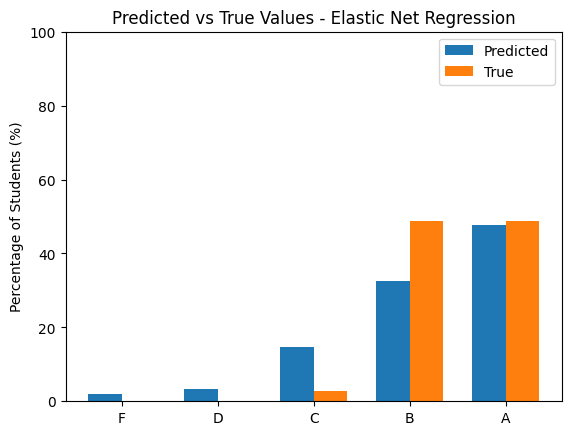

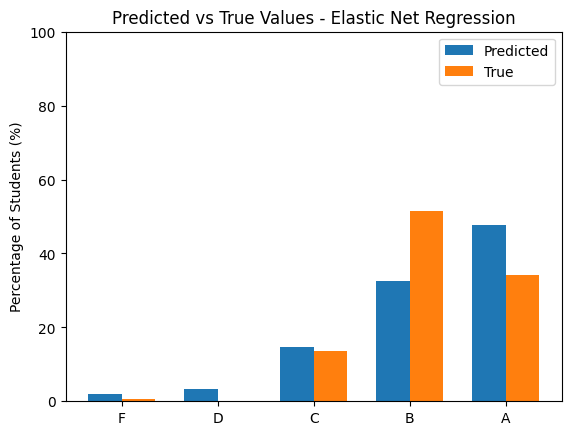

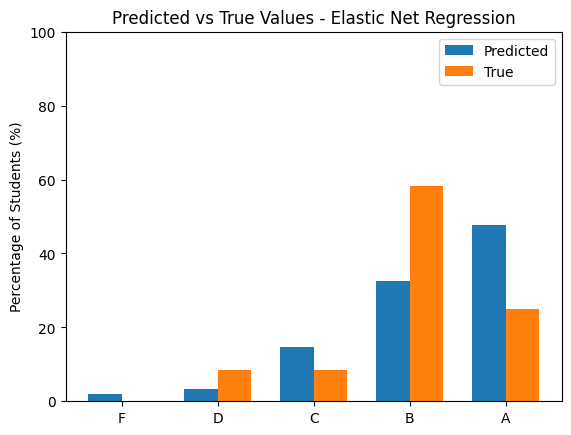

{8.132478595084443: 'Elastic Net Regression'}
Best Model and associated R2 Score: Elastic Net Regression: 8.132478595084443
#######################################################################
MODEL 2: NO QUIZ OR MISC


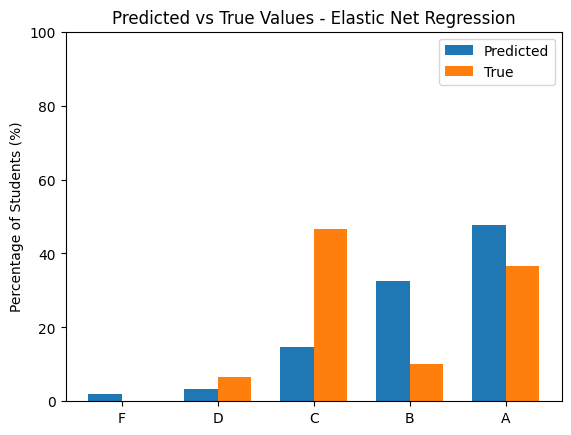

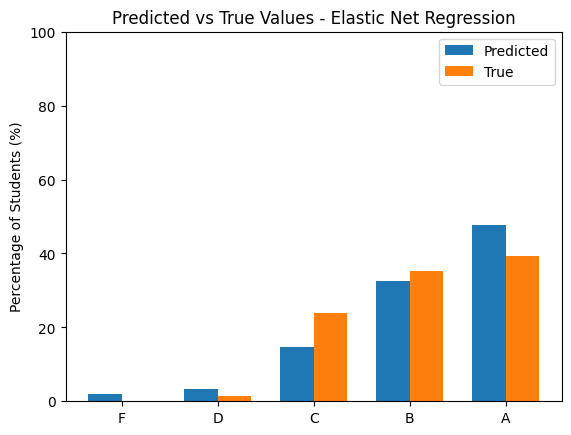

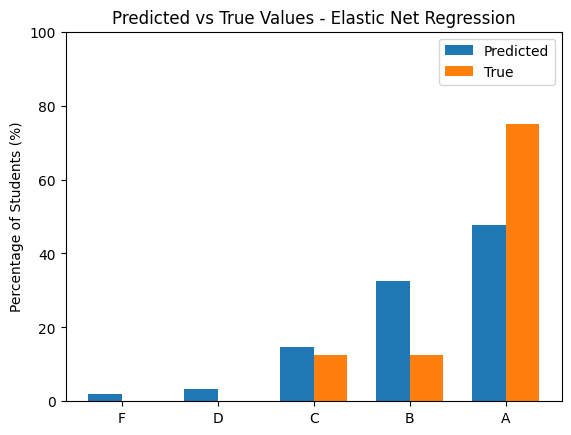

{8.132478595084443: 'Elastic Net Regression'}
Best Model and associated R2 Score: Elastic Net Regression: 8.132478595084443
#######################################################################
FINAL RESULTS:
Best OVERALL Model and Data Grouping with associated MAE Score: Elastic Net Regression - MODEL 2: NO QUIZ OR MISC: 8.132478595084443


In [ ]:
"""
GENERATED DATA MODELS
"""
import warnings
warnings.filterwarnings("ignore")

model_dict = {}
# -----------------------------------------------------------------------------------------------------
# MODEL 1: ALL PARAMETERS
X_train = pd.read_csv('XDataImport  -100,000.csv')
Y_train = pd.read_csv('YDataImport  -100,000.csv')
X_test = pd.read_csv('Final Datasheet - XDataImport.csv')
Y_test = pd.read_csv('Final Datasheet - YDataImport - DISTRIBUTION.csv')

X_train = X_train.to_numpy()
Y_train = Y_train.to_numpy()[:,0:5]
X_test = X_test.to_numpy()
X_test = X_test[0:len(X_test)-1]
Y_test = Y_test.to_numpy()
Y_test = Y_test[0:len(Y_test)-1]

print("MODEL 1: ALL PARAMETERS")
mae_dict1 = generated_run_regression_models(X_train, Y_train, X_test, Y_test, show_error = False, run_all = False, run_enet = True)
print(mae_dict1)
best_mae = min(mae_dict1)
print(f'Best Model and associated R2 Score: {mae_dict1[best_mae]}: {best_mae}')
model_dict.update({best_mae: f'{mae_dict1[best_mae]} - MODEL 1: ALL PARAMETERS'})
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 2: NO QUIZ OR MISC
X_train = pd.read_csv('XDataImport  -100,000  - NO QUIZ OR MISC.csv')
Y_train = pd.read_csv('YDataImport  -100,000.csv')
X_test = pd.read_csv('Final Datasheet - XDataImport - NO QUIZ OR MISC.csv')
Y_test = pd.read_csv('Final Datasheet - YDataImport - DISTRIBUTION.csv')

X_train = X_train.to_numpy()
Y_train = Y_train.to_numpy()[:,0:5]
X_test = X_test.to_numpy()
X_test = X_test[0:len(X_test)-1]
Y_test = Y_test.to_numpy()
Y_test = Y_test[0:len(Y_test)-1]

print("MODEL 2: NO QUIZ OR MISC")
mae_dict2 = generated_run_regression_models(X_train, Y_train, X_test, Y_test, show_error = False, run_all = False, run_enet = True)
print(mae_dict2)
best_mae = min(mae_dict2)
print(f'Best Model and associated R2 Score: {mae_dict2[best_mae]}: {best_mae}')
model_dict.update({best_mae: f'{mae_dict2[best_mae]} - MODEL 2: NO QUIZ OR MISC'})
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# FINAL RESULTS:
print("FINAL RESULTS:")
print(f'Best OVERALL Model and Data Grouping with associated MAE Score: {model_dict[min(model_dict)]}: {min(model_dict)}')

# **BLOW THIS POINT ARE MODELS THAT HAVE NOT BEEN 100% OPTIMIZED ACROSS MULTIPLE SEEDS, AND ARE ONLY OPTIMIZED ON THE CURRENT SEED BEING RUN**

# GRADE LETTER GRADE RANKING MODELS - KNN Regression & KNN Classification (1 = Least Amnt of Students, 5 = Greatest Amnt of Students)

**KNN REGRESSION**

MODEL 1: ALL PARAMETERS


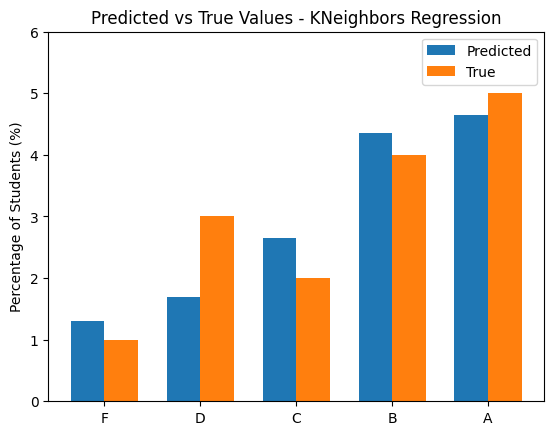

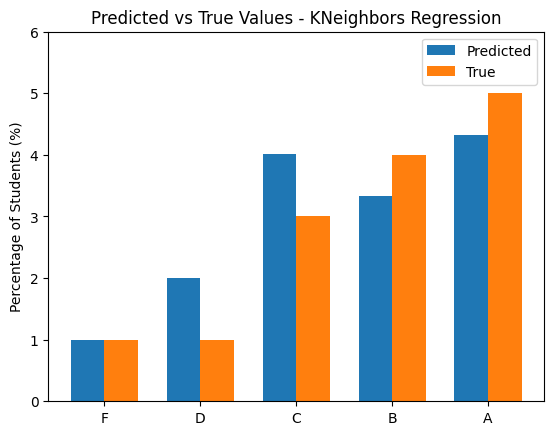

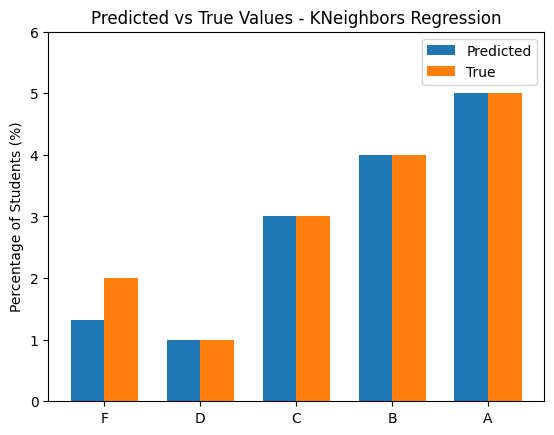

{17.104761904761904: 'Random Forest Regression', 17.104761904761908: 'Decision Tree Regression', 0.4745948704252334: 'KNeighbors Regression'}
Best Model and associated MAE Score: KNeighbors Regression: 0.4745948704252334
#######################################################################
MODEL 2: NO QUIZ OR MISC


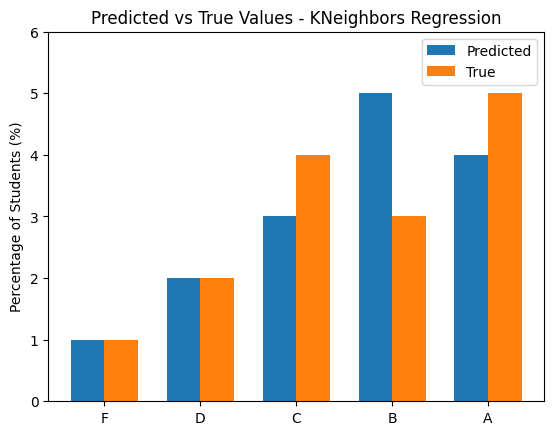

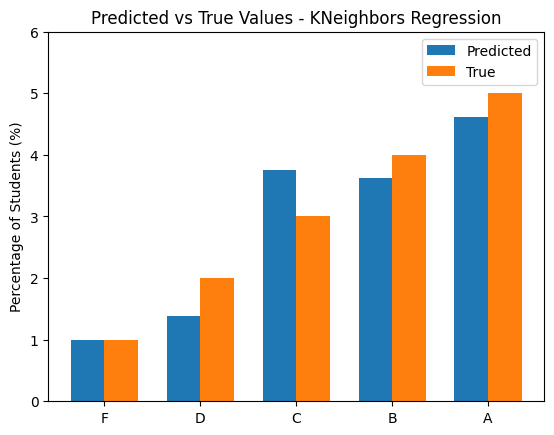

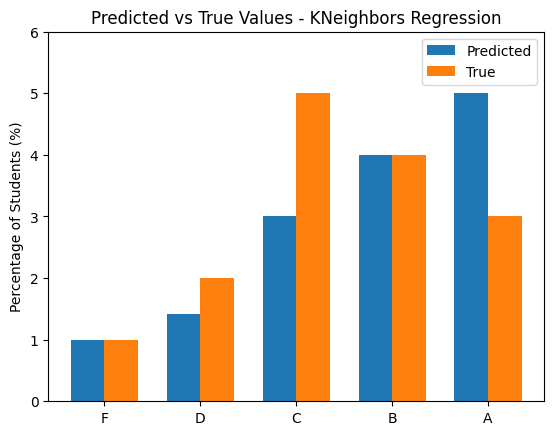

{17.104761904761904: 'Random Forest Regression', 0.5277983640548454: 'KNeighbors Regression'}
Best Model and associated MAE Score: KNeighbors Regression: 0.5277983640548454
#######################################################################
MODEL 3: EXAMS & HW ONLY


KeyboardInterrupt: 

In [ ]:
"""
GRADE RANK MODELS
"""
import warnings
warnings.filterwarnings("ignore")

model_dict = {}
# -----------------------------------------------------------------------------------------------------
# MODEL 1: ALL PARAMETERS
X_data = pd.read_csv('Final Datasheet - XDataImport.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - GRADERANK.csv')

print("MODEL 1: ALL PARAMETERS")
mae_dict1 = run_regression_models(X_data, Y_data, show_error = False, y_max = 6)
print(mae_dict1)
best_mae = min(mae_dict1)
print(f'Best Model and associated MAE Score: {mae_dict1[best_mae]}: {best_mae}')
model_dict.update({best_mae: f'{mae_dict1[best_mae]} - MODEL 1: ALL PARAMETERS'})
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 2: NO QUIZ OR MISC
X_data = pd.read_csv('Final Datasheet - XDataImport - NO QUIZ OR MISC.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - GRADERANK.csv')

print("MODEL 2: NO QUIZ OR MISC")
mae_dict2 = run_regression_models(X_data, Y_data, show_error = False, y_max = 6)
print(mae_dict2)
best_mae = min(mae_dict2)
print(f'Best Model and associated MAE Score: {mae_dict2[best_mae]}: {best_mae}')
model_dict.update({best_mae: f'{mae_dict2[best_mae]} - MODEL 2: NO QUIZ OR MISC'})
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 3: EXAMS & HW ONLY
X_data = pd.read_csv('Final Datasheet - XDataImport - EXAMS & HW ONLY.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - GRADERANK.csv')

print("MODEL 3: EXAMS & HW ONLY")
mae_dict3 = run_regression_models(X_data, Y_data, show_error = False, y_max = 6)
print(mae_dict3)
best_mae = min(mae_dict3)
print(f'Best Model and associated MAE Score: {mae_dict3[best_mae]}: {best_mae}')
model_dict.update({best_mae: f'{mae_dict3[best_mae]} - MODEL 3: EXAMS & HW ONLY'})
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 4: EXAMS (COMBINED) & HW ONLY
X_data = pd.read_csv('Final Datasheet - XDataImport - EXAMS (COMBINED) & HW ONLY.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - GRADERANK.csv')

print("MODEL 4: EXAMS (COMBINED) & HW ONLY")
mae_dict4 = run_regression_models(X_data, Y_data, show_error = False, y_max = 6)
print(mae_dict4)
best_mae = min(mae_dict4)
print(f'Best Model and associated MAE Score: {mae_dict4[best_mae]}: {best_mae}')
model_dict.update({best_mae: f'{mae_dict4[best_mae]} - MODEL 4: EXAMS (COMBINED) & HW ONLY'})
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 5: WEIGHTS ONLY
X_data = pd.read_csv('Final Datasheet - XDataImport - WEIGHTS ONLY.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - GRADERANK.csv')

print("MODEL 5: WEIGHTS ONLY")
mae_dict5 = run_regression_models(X_data, Y_data, show_error = False, y_max = 6)
print(mae_dict5)
best_mae = min(mae_dict5)
print(f'Best Model and associated MAE Score: {mae_dict5[best_mae]}: {best_mae}')
model_dict.update({best_mae: f'{mae_dict5[best_mae]} - MODEL 5: WEIGHTS ONLY'})
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# FINAL RESULTS:
print("FINAL RESULTS:")
print(f'Best OVERALL Model and Data Grouping with associated MAE Score: {model_dict[min(model_dict)]}: {min(model_dict)}')


**KNN CLASSIFIER**

In [ ]:
# KNN CLASSIFIER
def run_knn_classification(X_data, Y_data, labels=["F", "D", "C", "B", "A"], data_is_pandas=True, seed=42):
    if data_is_pandas:
        X_data = pd.DataFrame.to_numpy(X_data)
        Y_data = pd.DataFrame.to_numpy(Y_data)
        X_data = X_data[0:len(X_data)-1]
        Y_data = Y_data[0:len(Y_data)-1]
    X_data = X_data.astype(np.float64)
    Y_data = Y_data.astype(int)

    # Create train and test data
    X_train, X_test, Y_train, Y_test = train_test_split(X_data, Y_data, test_size=0.2, random_state=seed)

    # SCALE THE DATA
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    params = {
        'estimator__n_neighbors': [3, 5, 7],
        'estimator__weights': ['uniform', 'distance'],
        'estimator__p': [1, 2]
    }

    knn_classifier = MultiOutputClassifier(KNeighborsClassifier())
    grid_search = GridSearchCV(knn_classifier, params, cv=3, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_scaled, Y_train)

    best_model = grid_search.best_estimator_
    Y_pred = best_model.predict(X_test_scaled)

    # Calculate Accuracy for subset
    for i in range(Y_train.shape[1]):
        accuracy = accuracy_score(Y_test[:, i], Y_pred[:, i])
        print(f"Output {i + 1} Accuracy: {accuracy:.4f}")

    for i in range(3):
        random_index = random.randint(0, 20)
        graph_distributions(Y_pred[random_index], Y_test[random_index], model_type=f"KNeighbors Classification", labels=labels, y_max=5)

# -----------------------------------------------------------------------------------------------------
# CUSTOM ERROR CALCULATION
def custom_error(y_true, y_pred, threshold = 5):
  error = 0
  y_true = y_true.astype(np.float64)
  for i in range(len(y_true)):
    for j in range(len(y_true[i])):
      if abs(y_true[i][j] - y_pred[i][j]) > threshold:
        error += 1
  return error/(5*len(y_true))

# -----------------------------------------------------------------------------------------------------
# Histogram Code

def graph_distributions(Y_pred, Y_test, model_type, labels, y_max):
  x = np.arange(len(labels))
  width = 0.35
  plt.bar(x - width/2, Y_pred, width, label='Predicted')
  plt.bar(x + width/2, Y_test, width, label='True')
  plt.xticks(x, labels)
  plt.ylabel("Percentage of Students (%)")
  plt.ylim(0, y_max)
  plt.title(f'Predicted vs True Values - {model_type}')
  plt.legend()
  plt.show()

# -----------------------------------------------------------------------------------------------------

MODEL 1: ALL PARAMETERS
Output 1 Accuracy: 0.6667
Output 2 Accuracy: 0.7143
Output 3 Accuracy: 0.7143
Output 4 Accuracy: 0.6667
Output 5 Accuracy: 0.6667


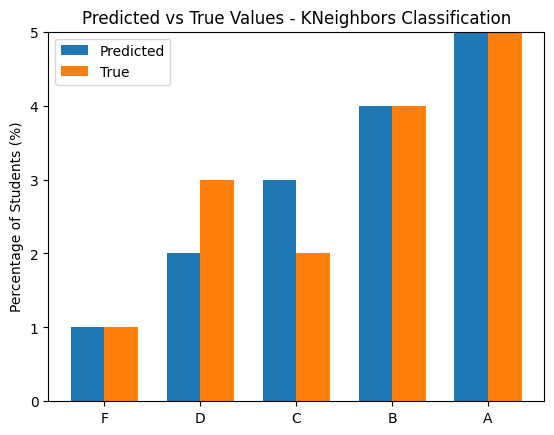

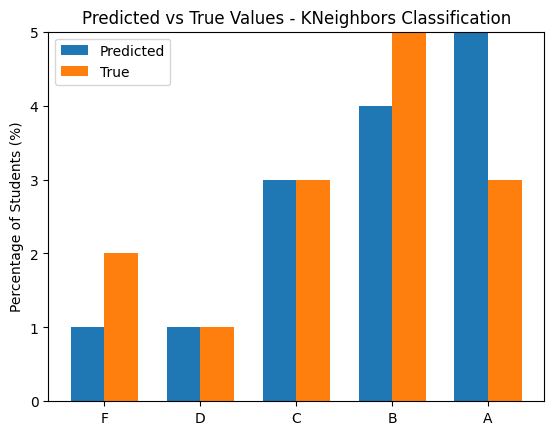

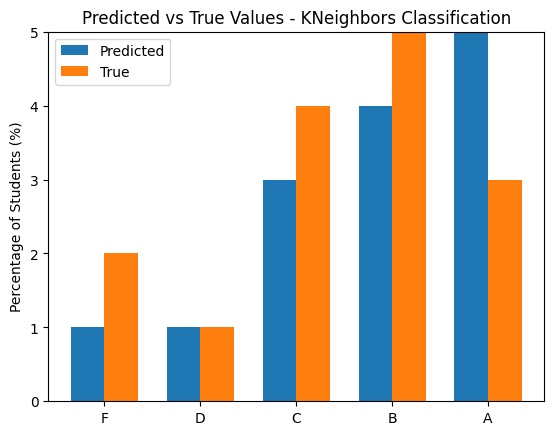

#######################################################################
MODEL 2: NO QUIZ OR MISC
Output 1 Accuracy: 0.7143
Output 2 Accuracy: 0.5714
Output 3 Accuracy: 0.4762
Output 4 Accuracy: 0.5714
Output 5 Accuracy: 0.6667


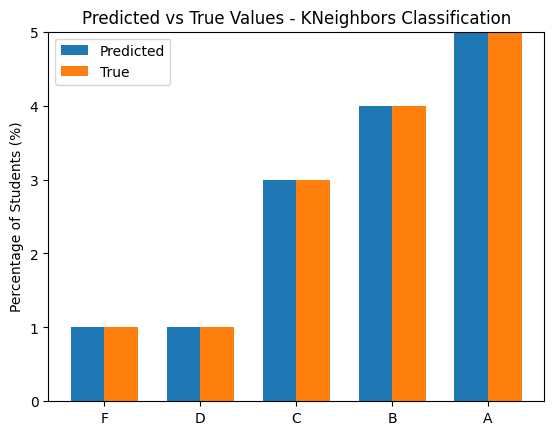

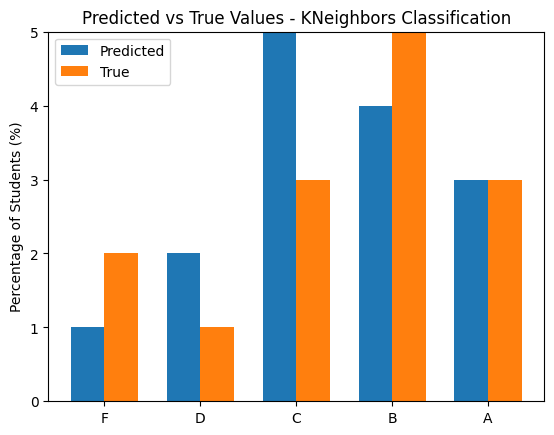

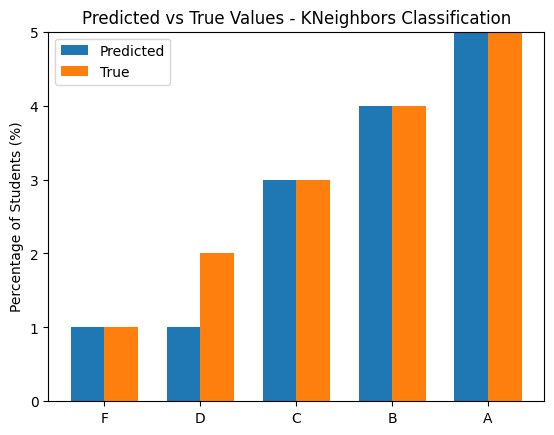

#######################################################################
MODEL 3: EXAMS & HW ONLY
Output 1 Accuracy: 0.6667
Output 2 Accuracy: 0.5714
Output 3 Accuracy: 0.7143
Output 4 Accuracy: 0.4286
Output 5 Accuracy: 0.4762


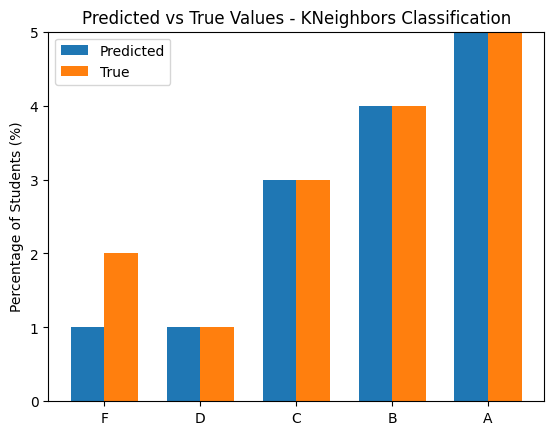

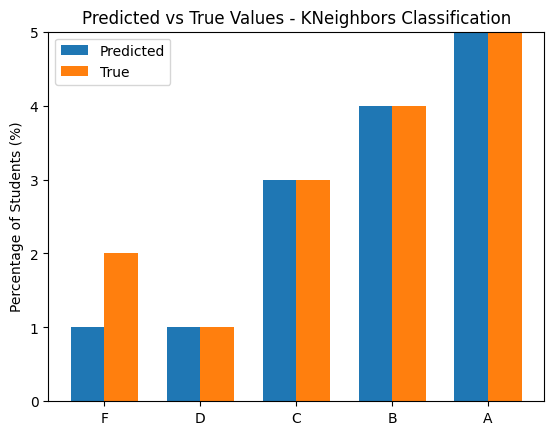

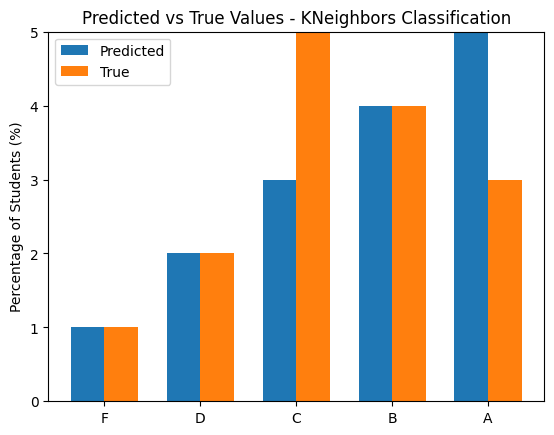

#######################################################################
MODEL 4: EXAMS (COMBINED) & HW ONLY
Output 1 Accuracy: 0.6667
Output 2 Accuracy: 0.4286
Output 3 Accuracy: 0.5238
Output 4 Accuracy: 0.5238
Output 5 Accuracy: 0.5714


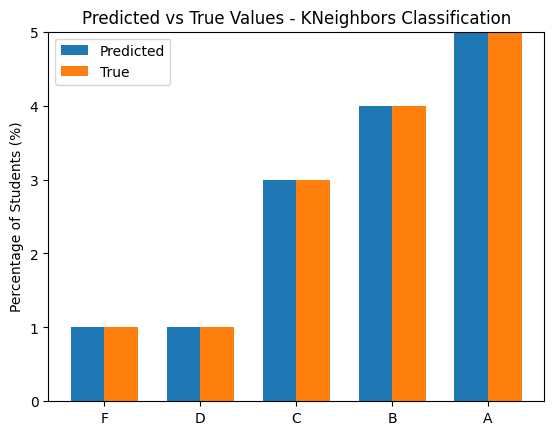

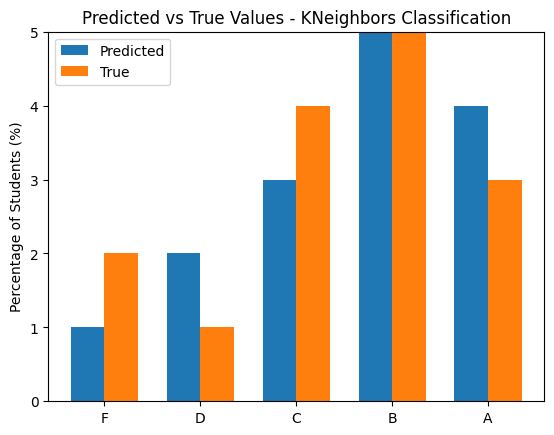

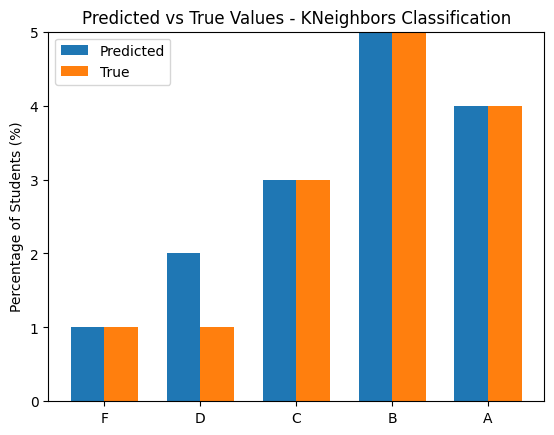

#######################################################################
MODEL 5: WEIGHTS ONLY
Output 1 Accuracy: 0.6667
Output 2 Accuracy: 0.4762
Output 3 Accuracy: 0.7143
Output 4 Accuracy: 0.5714
Output 5 Accuracy: 0.5238


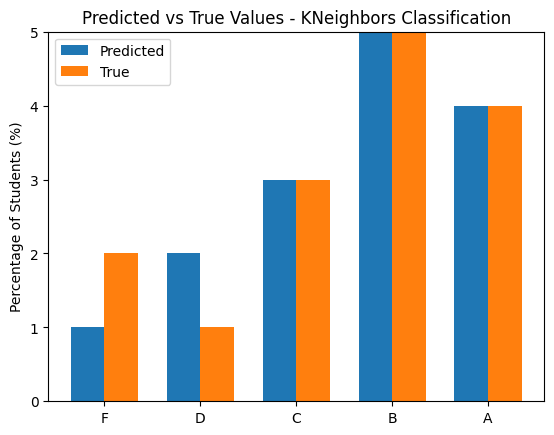

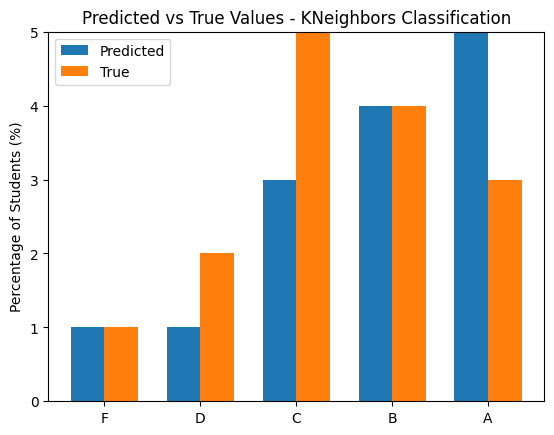

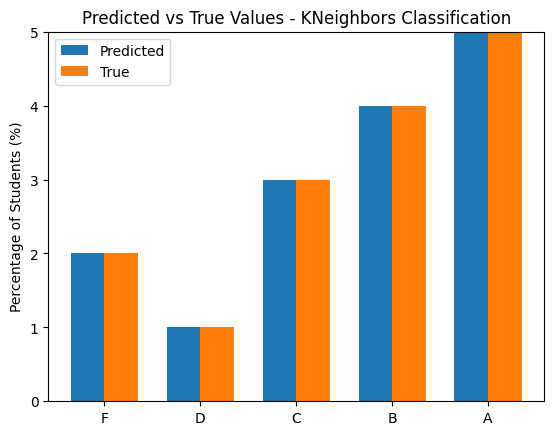

#######################################################################


In [ ]:
"""
GRADE RANK MODELS
"""
import warnings
warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------------------------------
# MODEL 1: ALL PARAMETERS
X_data = pd.read_csv('Final Datasheet - XDataImport.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - GRADERANK.csv')

print("MODEL 1: ALL PARAMETERS")
run_knn_classification(X_data, Y_data)
print("#######################################################################")

# -----------------------------------------------------------------------------------------------------
# MODEL 2: NO QUIZ OR MISC
X_data = pd.read_csv('Final Datasheet - XDataImport - NO QUIZ OR MISC.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - GRADERANK.csv')

print("MODEL 2: NO QUIZ OR MISC")
run_knn_classification(X_data, Y_data)
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 3: EXAMS & HW ONLY
X_data = pd.read_csv('Final Datasheet - XDataImport - EXAMS & HW ONLY.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - GRADERANK.csv')

print("MODEL 3: EXAMS & HW ONLY")
run_knn_classification(X_data, Y_data)
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 4: EXAMS (COMBINED) & HW ONLY
X_data = pd.read_csv('Final Datasheet - XDataImport - EXAMS (COMBINED) & HW ONLY.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - GRADERANK.csv')

print("MODEL 4: EXAMS (COMBINED) & HW ONLY")
run_knn_classification(X_data, Y_data)
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 5: WEIGHTS ONLY
X_data = pd.read_csv('Final Datasheet - XDataImport - WEIGHTS ONLY.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - GRADERANK.csv')

print("MODEL 5: WEIGHTS ONLY")
run_knn_classification(X_data, Y_data)
print("#######################################################################")
# ----------------------------------------------------------------------------------------------------


# PASS FAIL MODELS

MODEL 1: ALL PARAMETERS


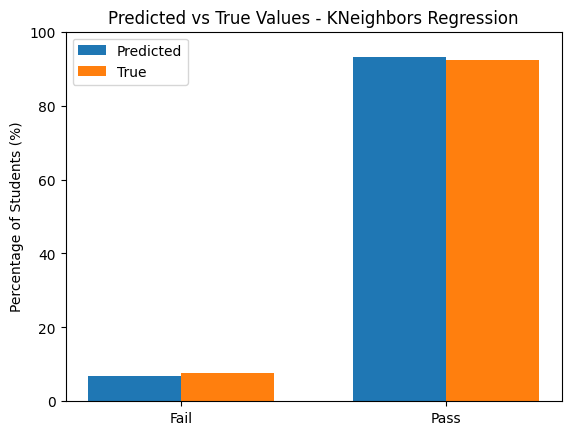

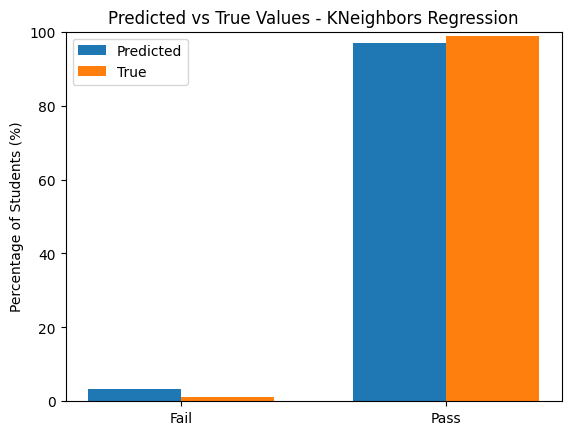

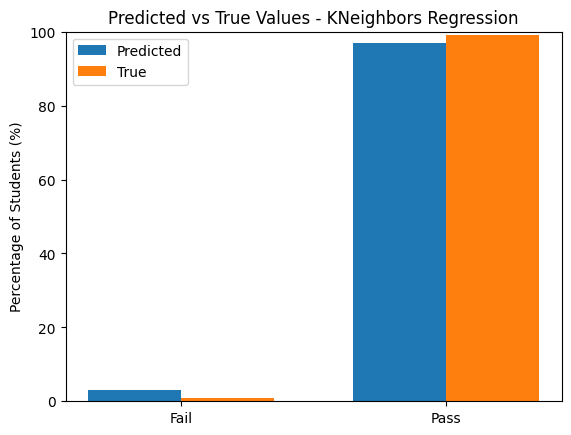

{3.419351941018766: 'Linear Regression', 3.5029516222937724: 'Ridge Regression', 3.4937299514051325: 'Lasso Regression', 3.475705172351134: 'Elastic Net Regression', 3.86455768069351: 'Decision Tree Regression', 3.7206015689071776: 'Random Forest Regression', 2.9264285714285716: 'KNeighbors Regression'}
Best Model and associated MAE Score: KNeighbors Regression: 2.9264285714285716
#######################################################################
MODEL 2: NO QUIZ OR MISC


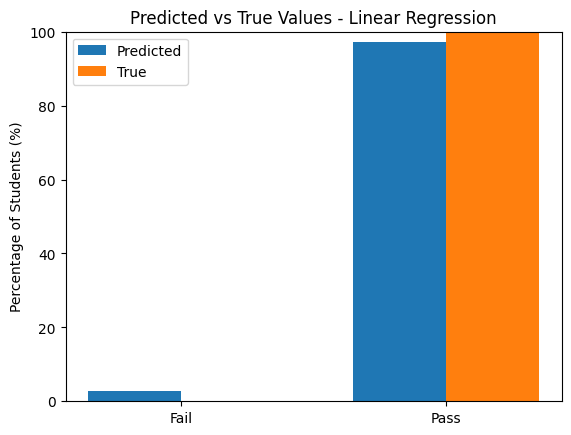

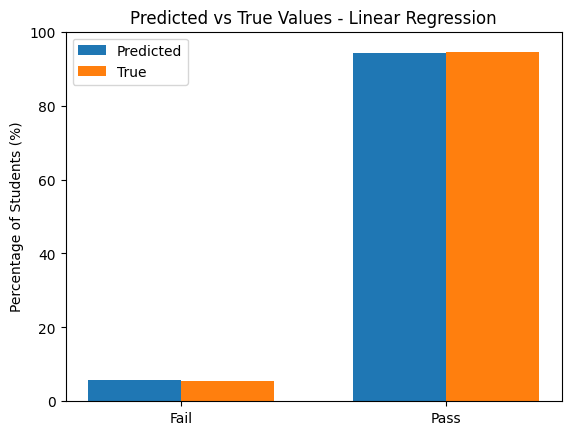

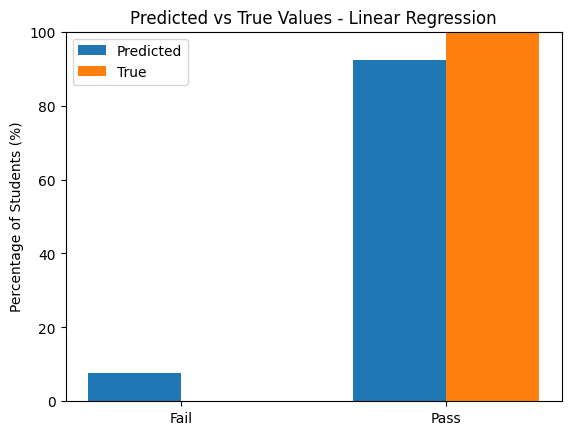

{3.1487518025524737: 'Linear Regression', 3.156405062445453: 'Ridge Regression', 3.1852544210199696: 'Lasso Regression', 3.184286483746443: 'Elastic Net Regression', 3.86455768069351: 'Decision Tree Regression', 3.398008215770145: 'Random Forest Regression', 3.433945578231293: 'KNeighbors Regression'}
Best Model and associated MAE Score: Linear Regression: 3.1487518025524737
#######################################################################
MODEL 3: EXAMS & HW ONLY


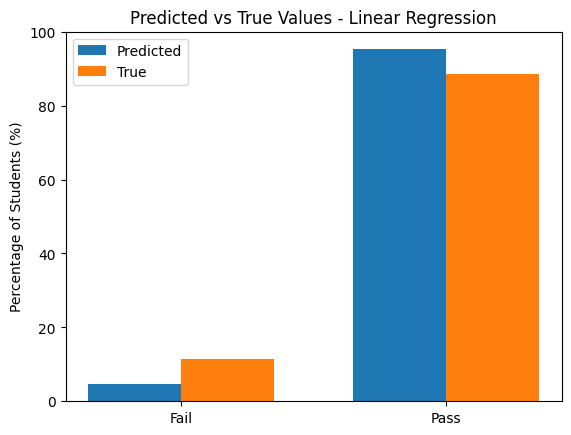

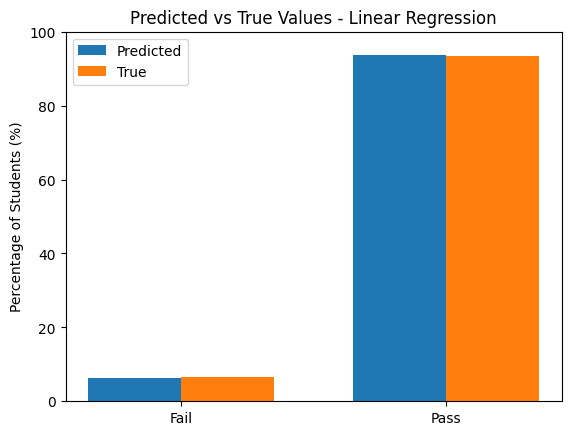

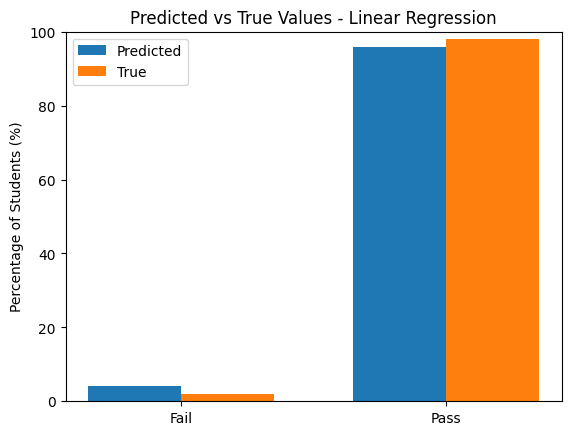

{3.3058457739363702: 'Linear Regression', 3.3058917264157657: 'Ridge Regression', 3.309728651292386: 'Lasso Regression', 3.309715263161549: 'Elastic Net Regression', 4.601693866251629: 'Decision Tree Regression', 3.692335804348162: 'Random Forest Regression', 3.335544217687075: 'KNeighbors Regression'}
Best Model and associated MAE Score: Linear Regression: 3.3058457739363702
#######################################################################
MODEL 4: EXAMS (COMBINED) & HW ONLY


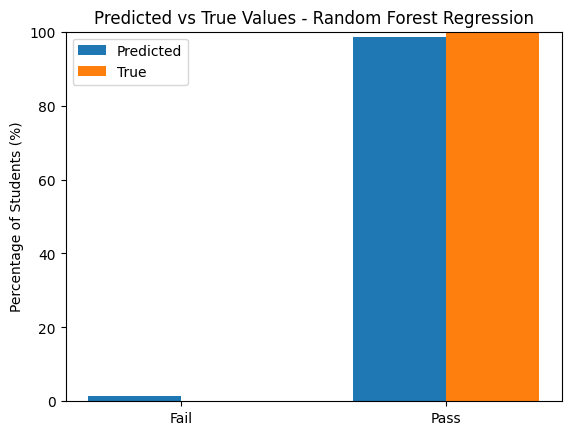

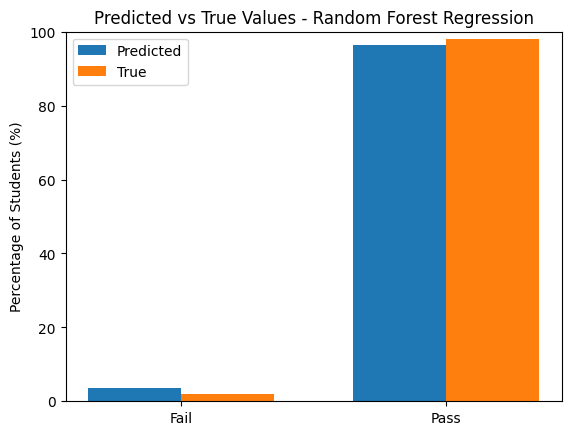

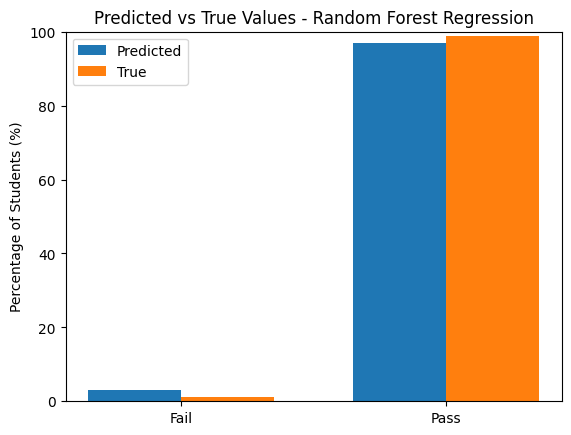

{3.8188043156978675: 'Linear Regression', 3.874137820380286: 'Ridge Regression', 3.6890720953795224: 'Lasso Regression', 3.7781425661520798: 'Elastic Net Regression', 3.6843461829176114: 'Decision Tree Regression', 3.666841631660101: 'Random Forest Regression', 4.008015873015873: 'KNeighbors Regression'}
Best Model and associated MAE Score: Random Forest Regression: 3.666841631660101
#######################################################################
MODEL 5: WEIGHTS ONLY


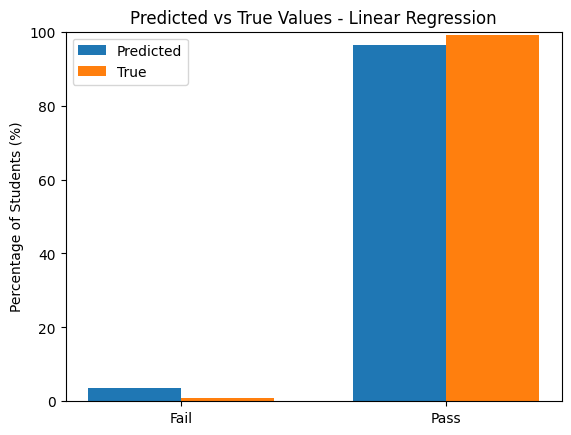

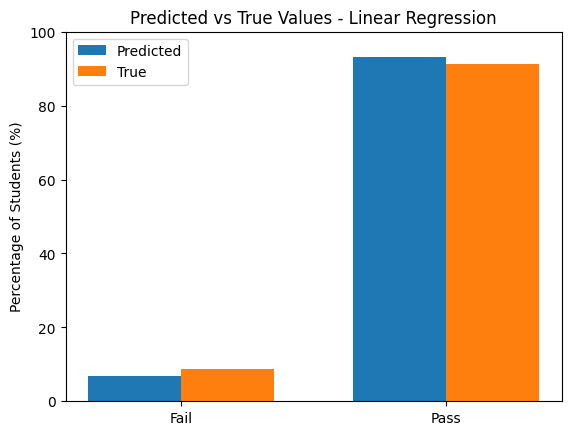

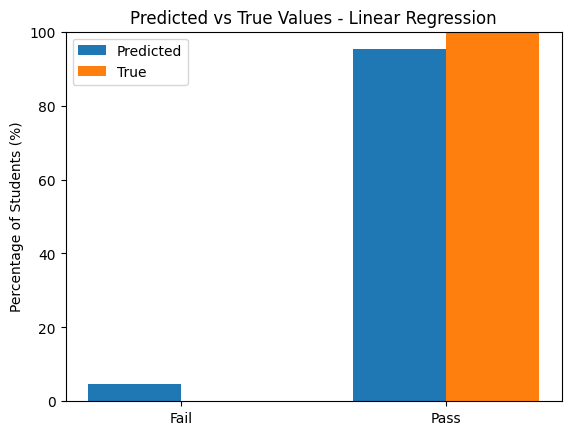

{3.1633021340832164: 'Linear Regression', 3.1633871401906646: 'Ridge Regression', 3.1706987611266912: 'Lasso Regression', 3.1702125183435026: 'Elastic Net Regression', 4.174998283804089: 'Decision Tree Regression', 3.549679410783712: 'Random Forest Regression', 3.259489795918368: 'KNeighbors Regression'}
Best Model and associated MAE Score: Linear Regression: 3.1633021340832164
#######################################################################
FINAL RESULTS:
Best OVERALL Model and Data Grouping with associated MAE Score: KNeighbors Regression - MODEL 1: ALL PARAMETERS: 2.9264285714285716


In [ ]:
"""
PASS/FAIL MODELS
"""
import warnings
warnings.filterwarnings("ignore")
model_dict = {}
# -----------------------------------------------------------------------------------------------------
# MODEL 1: ALL PARAMETERS
X_data = pd.read_csv('Final Datasheet - XDataImport.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - PASS_FAIL.csv')

print("MODEL 1: ALL PARAMETERS")
mae_dict1 = run_regression_models(X_data, Y_data, show_error = False, labels = ["Fail", "Pass"])
print(mae_dict1)
best_mae = min(mae_dict1)
print(f'Best Model and associated MAE Score: {mae_dict1[best_mae]}: {best_mae}')
model_dict.update({best_mae: f'{mae_dict1[best_mae]} - MODEL 1: ALL PARAMETERS'})
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 2: NO QUIZ OR MISC
X_data = pd.read_csv('Final Datasheet - XDataImport - NO QUIZ OR MISC.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - PASS_FAIL.csv')

print("MODEL 2: NO QUIZ OR MISC")
mae_dict2 = run_regression_models(X_data, Y_data, show_error = False, labels = ["Fail", "Pass"])
print(mae_dict2)
best_mae = min(mae_dict2)
print(f'Best Model and associated MAE Score: {mae_dict2[best_mae]}: {best_mae}')
model_dict.update({best_mae: f'{mae_dict2[best_mae]} - MODEL 2: NO QUIZ OR MISC'})
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 3: EXAMS & HW ONLY
X_data = pd.read_csv('Final Datasheet - XDataImport - EXAMS & HW ONLY.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - PASS_FAIL.csv')

print("MODEL 3: EXAMS & HW ONLY")
mae_dict3 = run_regression_models(X_data, Y_data, show_error = False, labels = ["Fail", "Pass"])
print(mae_dict3)
best_mae = min(mae_dict3)
print(f'Best Model and associated MAE Score: {mae_dict3[best_mae]}: {best_mae}')
model_dict.update({best_mae: f'{mae_dict3[best_mae]} - MODEL 3: EXAMS & HW ONLY'})
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 4: EXAMS (COMBINED) & HW ONLY
X_data = pd.read_csv('Final Datasheet - XDataImport - EXAMS (COMBINED) & HW ONLY.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - PASS_FAIL.csv')

print("MODEL 4: EXAMS (COMBINED) & HW ONLY")
mae_dict4 = run_regression_models(X_data, Y_data, show_error = False, labels = ["Fail", "Pass"])
print(mae_dict4)
best_mae = min(mae_dict4)
print(f'Best Model and associated MAE Score: {mae_dict4[best_mae]}: {best_mae}')
model_dict.update({best_mae: f'{mae_dict4[best_mae]} - MODEL 4: EXAMS (COMBINED) & HW ONLY'})
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 5: WEIGHTS ONLY
X_data = pd.read_csv('Final Datasheet - XDataImport - WEIGHTS ONLY.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - PASS_FAIL.csv')

print("MODEL 5: WEIGHTS ONLY")
mae_dict5 = run_regression_models(X_data, Y_data, show_error = False, labels = ["Fail", "Pass"])
print(mae_dict5)
best_mae = min(mae_dict5)
print(f'Best Model and associated MAE Score: {mae_dict5[best_mae]}: {best_mae}')
model_dict.update({best_mae: f'{mae_dict5[best_mae]} - MODEL 5: WEIGHTS ONLY'})
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# FINAL RESULTS:
print("FINAL RESULTS:")
print(f'Best OVERALL Model and Data Grouping with associated MAE Score: {model_dict[min(model_dict)]}: {min(model_dict)}')




# PASS/FAIL MODELS - IN DEPTH (STRONG PASS (A,B), MEDIUM PASS (C), FAIL (D,F))

MODEL 1: ALL PARAMETERS


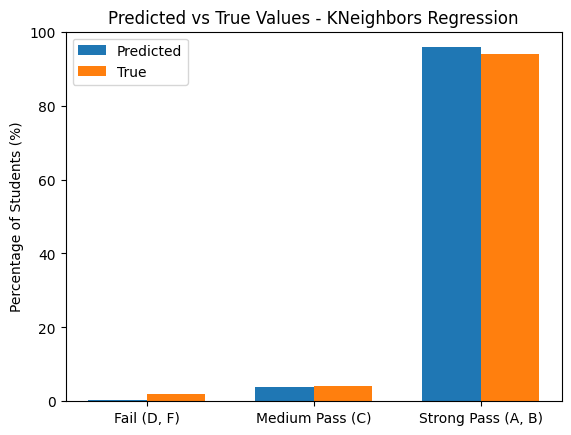

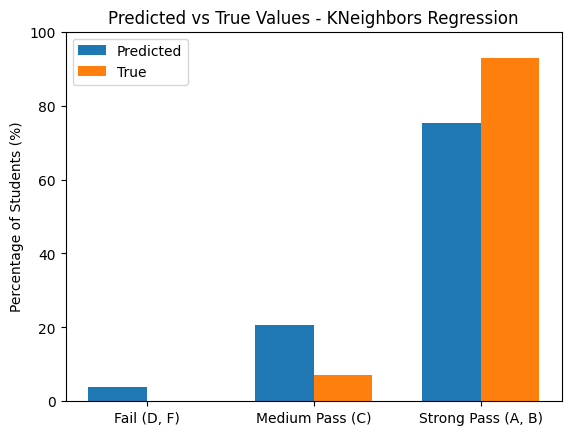

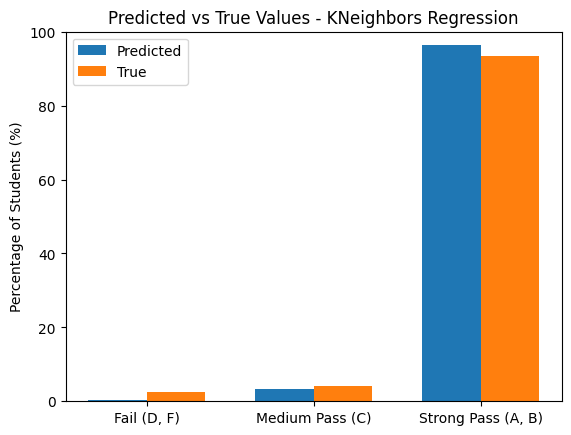

{7.7550047953119: 'Linear Regression', 7.828113607960887: 'Ridge Regression', 7.638550223617687: 'Lasso Regression', 7.650640352692887: 'Elastic Net Regression', 8.398002142928826: 'Decision Tree Regression', 8.157518504904422: 'Random Forest Regression', 7.341615898684598: 'KNeighbors Regression'}
Best Model and associated MAE Score: KNeighbors Regression: 7.341615898684598
#######################################################################
MODEL 2: NO QUIZ OR MISC


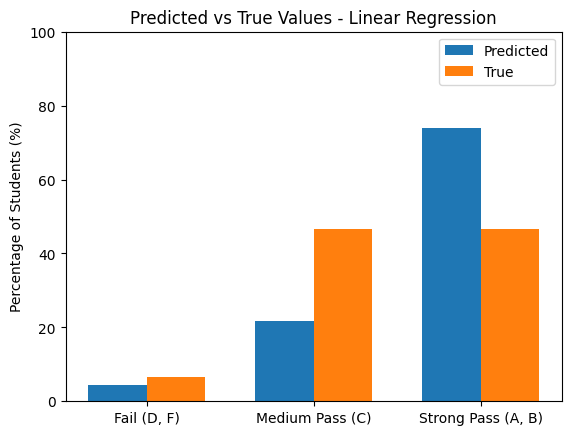

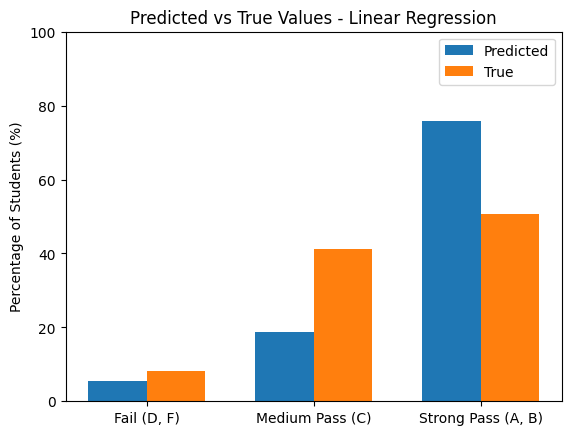

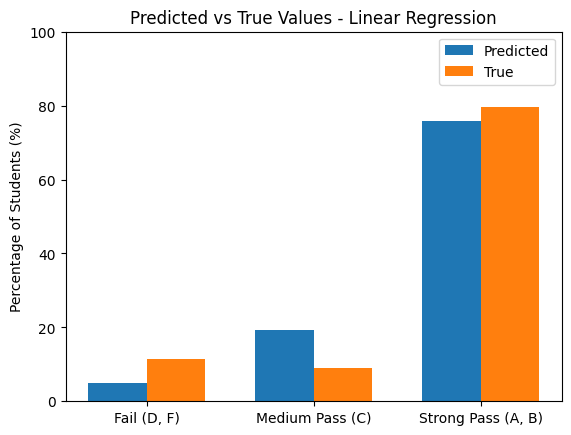

{7.185779055985008: 'Linear Regression', 7.223865416464161: 'Ridge Regression', 7.251415730676634: 'Lasso Regression', 7.234105147904355: 'Elastic Net Regression', 7.591915422370949: 'Decision Tree Regression', 7.8934601120131624: 'Random Forest Regression', 7.199235924513658: 'KNeighbors Regression'}
Best Model and associated MAE Score: Linear Regression: 7.185779055985008
#######################################################################
MODEL 3: EXAMS & HW ONLY


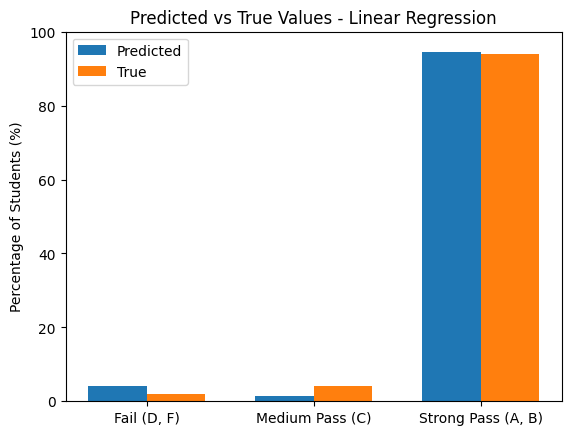

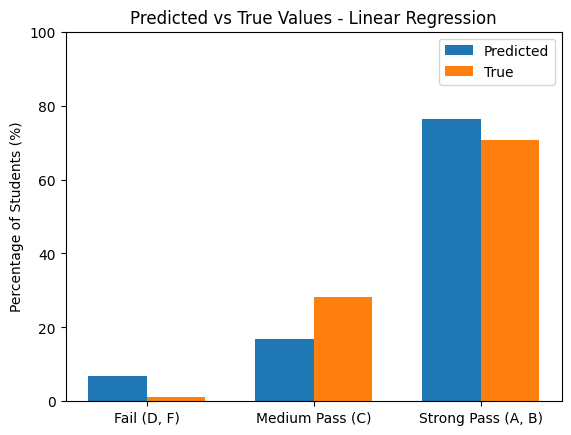

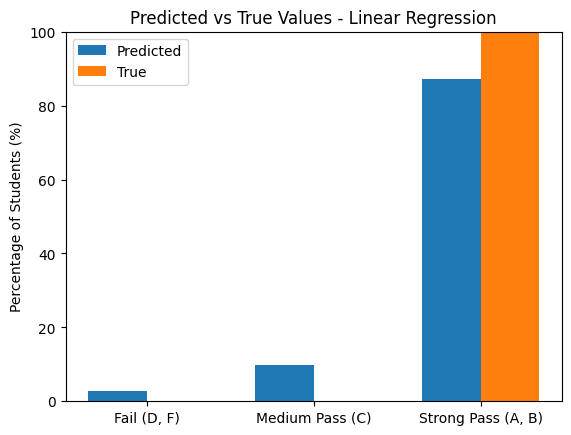

{7.225773856196375: 'Linear Regression', 7.227936323171768: 'Ridge Regression', 7.234016841927375: 'Lasso Regression', 7.234340259041093: 'Elastic Net Regression', 7.442956476563045: 'Decision Tree Regression', 7.981889475002622: 'Random Forest Regression', 7.3282993197278925: 'KNeighbors Regression'}
Best Model and associated MAE Score: Linear Regression: 7.225773856196375
#######################################################################
MODEL 4: EXAMS (COMBINED) & HW ONLY


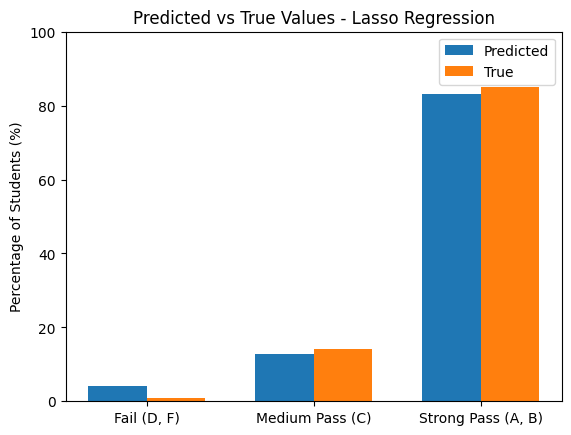

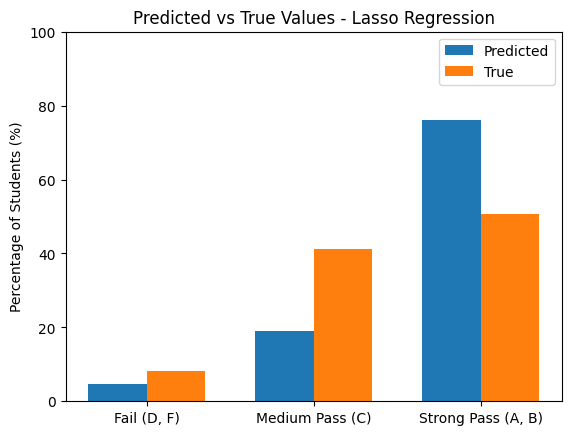

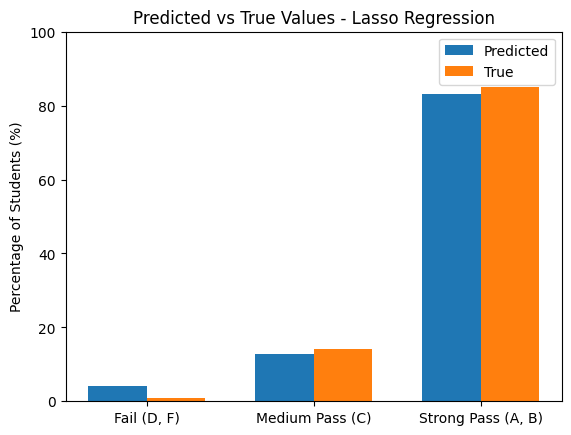

{7.696299232972566: 'Linear Regression', 7.673809331378479: 'Ridge Regression', 7.658024421257221: 'Lasso Regression', 7.66185046014909: 'Elastic Net Regression', 8.046684805597154: 'Decision Tree Regression', 7.815257195899427: 'Random Forest Regression', 9.38830687830688: 'KNeighbors Regression'}
Best Model and associated MAE Score: Lasso Regression: 7.658024421257221
#######################################################################
MODEL 5: WEIGHTS ONLY


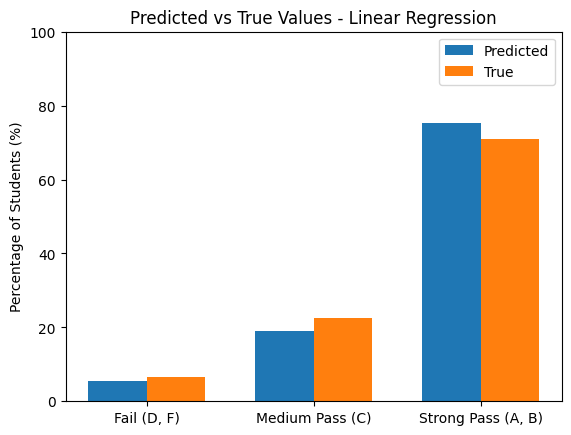

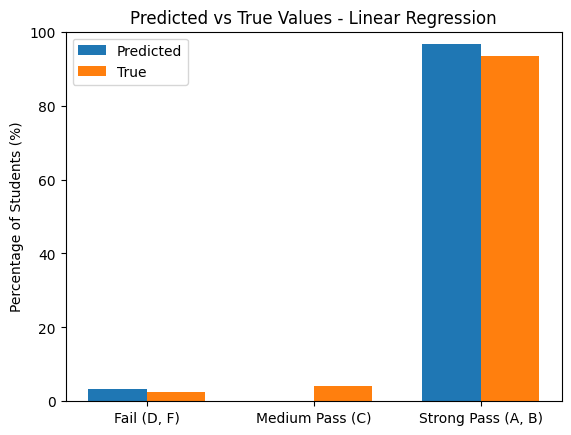

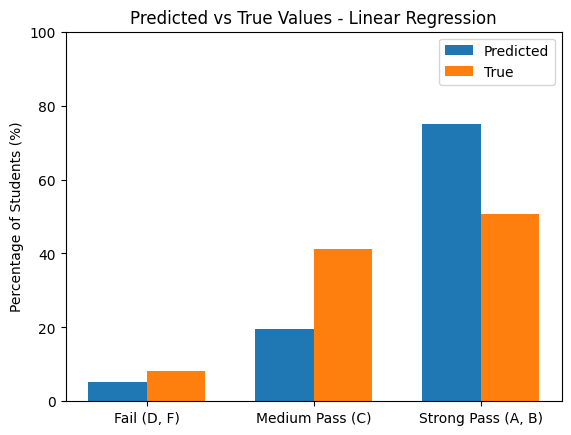

{7.2811550537256196: 'Linear Regression', 7.2811910038925065: 'Ridge Regression', 7.284743619437104: 'Lasso Regression', 7.284113241998327: 'Elastic Net Regression', 8.398660945134582: 'Decision Tree Regression', 8.396321822000395: 'Random Forest Regression', 7.702114403904992: 'KNeighbors Regression'}
Best Model and associated MAE Score: Linear Regression: 7.2811550537256196
#######################################################################
FINAL RESULTS:
Best OVERALL Model and Data Grouping with associated MAE Score: Linear Regression - MODEL 2: NO QUIZ OR MISC: 7.185779055985008


In [ ]:
"""
PASS/FAIL MODELS
"""
import warnings
warnings.filterwarnings("ignore")

model_dict = {}
# -----------------------------------------------------------------------------------------------------
# MODEL 1: ALL PARAMETERS
X_data = pd.read_csv('Final Datasheet - XDataImport.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - PASS_FAIL - INDEPTH.csv')

print("MODEL 1: ALL PARAMETERS")
mae_dict1 = run_regression_models(X_data, Y_data, show_error = False, labels = ["Fail (D, F)", "Medium Pass (C)", "Strong Pass (A, B)"])
print(mae_dict1)
best_mae = min(mae_dict1)
print(f'Best Model and associated MAE Score: {mae_dict1[best_mae]}: {best_mae}')
model_dict.update({best_mae: f'{mae_dict1[best_mae]} - MODEL 1: ALL PARAMETERS'})
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 2: NO QUIZ OR MISC
X_data = pd.read_csv('Final Datasheet - XDataImport - NO QUIZ OR MISC.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - PASS_FAIL - INDEPTH.csv')

print("MODEL 2: NO QUIZ OR MISC")
mae_dict2 = run_regression_models(X_data, Y_data, show_error = False, labels = ["Fail (D, F)", "Medium Pass (C)", "Strong Pass (A, B)"])
print(mae_dict2)
best_mae = min(mae_dict2)
print(f'Best Model and associated MAE Score: {mae_dict2[best_mae]}: {best_mae}')
model_dict.update({best_mae: f'{mae_dict2[best_mae]} - MODEL 2: NO QUIZ OR MISC'})
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 3: EXAMS & HW ONLY
X_data = pd.read_csv('Final Datasheet - XDataImport - EXAMS & HW ONLY.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - PASS_FAIL - INDEPTH.csv')

print("MODEL 3: EXAMS & HW ONLY")
mae_dict3 = run_regression_models(X_data, Y_data, show_error = False, labels = ["Fail (D, F)", "Medium Pass (C)", "Strong Pass (A, B)"])
print(mae_dict3)
best_mae = min(mae_dict3)
print(f'Best Model and associated MAE Score: {mae_dict3[best_mae]}: {best_mae}')
model_dict.update({best_mae: f'{mae_dict3[best_mae]} - MODEL 3: EXAMS & HW ONLY'})
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 4: EXAMS (COMBINED) & HW ONLY
X_data = pd.read_csv('Final Datasheet - XDataImport - EXAMS (COMBINED) & HW ONLY.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - PASS_FAIL - INDEPTH.csv')

print("MODEL 4: EXAMS (COMBINED) & HW ONLY")
mae_dict4 = run_regression_models(X_data, Y_data, show_error = False, labels = ["Fail (D, F)", "Medium Pass (C)", "Strong Pass (A, B)"])
print(mae_dict4)
best_mae = min(mae_dict4)
print(f'Best Model and associated MAE Score: {mae_dict4[best_mae]}: {best_mae}')
model_dict.update({best_mae: f'{mae_dict4[best_mae]} - MODEL 4: EXAMS (COMBINED) & HW ONLY'})
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# MODEL 5: WEIGHTS ONLY
X_data = pd.read_csv('Final Datasheet - XDataImport - WEIGHTS ONLY.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - PASS_FAIL - INDEPTH.csv')

print("MODEL 5: WEIGHTS ONLY")
mae_dict5 = run_regression_models(X_data, Y_data, show_error = False, labels = ["Fail (D, F)", "Medium Pass (C)", "Strong Pass (A, B)"])
print(mae_dict5)
best_mae = min(mae_dict5)
print(f'Best Model and associated MAE Score: {mae_dict5[best_mae]}: {best_mae}')
model_dict.update({best_mae: f'{mae_dict5[best_mae]} - MODEL 5: WEIGHTS ONLY'})
print("#######################################################################")
# -----------------------------------------------------------------------------------------------------
# FINAL RESULTS:
print("FINAL RESULTS:")
print(f'Best OVERALL Model and Data Grouping with associated MAE Score: {model_dict[min(model_dict)]}: {min(model_dict)}')



# IMPACT OF INDIVIDUAL FEATURES

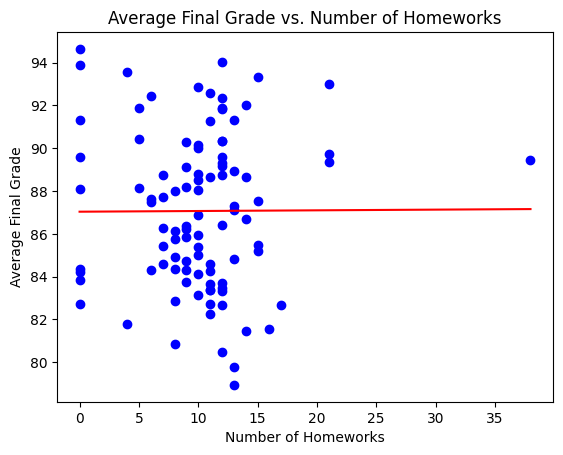

Slope: 0.0032125744916599824
Average Grade Change per Additional Assignment: 0.003%
Intercept: 87.03413522295092
R-squared: 2.172640622323921e-05


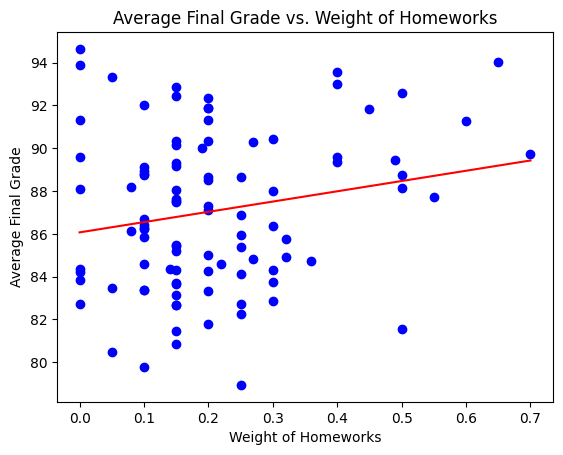

Slope: 4.79950290553576
Average Grade Change per Additional 1% Weight: 0.048%
Intercept: 86.06773607914414
R-squared: 0.03899966722864698


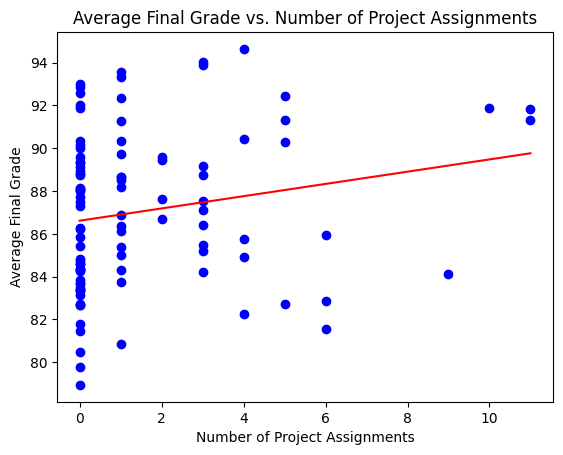

Slope: 0.2863952945246954
Average Grade Change per Additional Assignment: 0.286%
Intercept: 86.6133543811089
R-squared: 0.03736226698867511


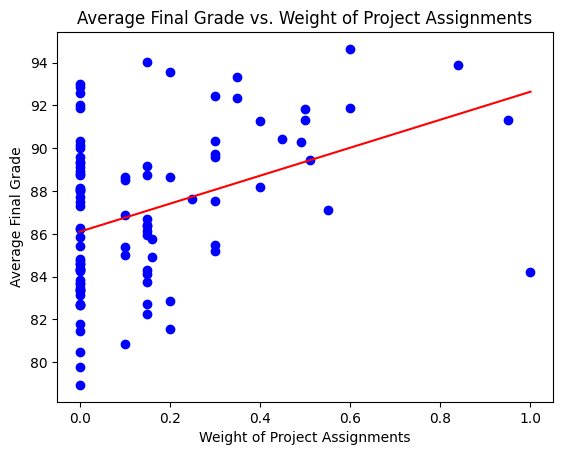

Slope: 6.542152880576096
Average Grade Change per Additional 1% Weight: 0.065%
Intercept: 86.0976873643147
R-squared: 0.1489386403462215


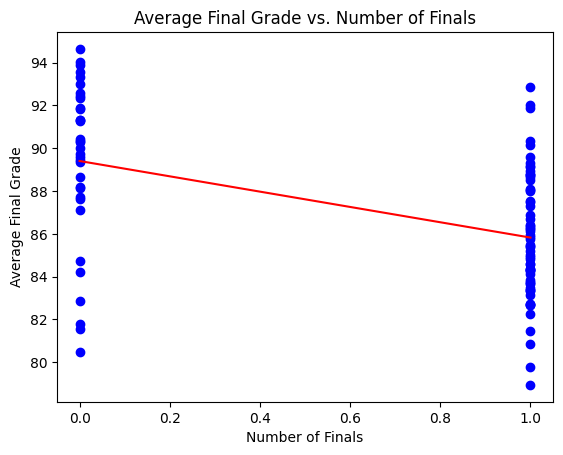

Slope: -3.5779411764705893
Average Grade Change per Additional Assignment: -3.578%
Intercept: 89.40294117647059
R-squared: 0.2195135539270279


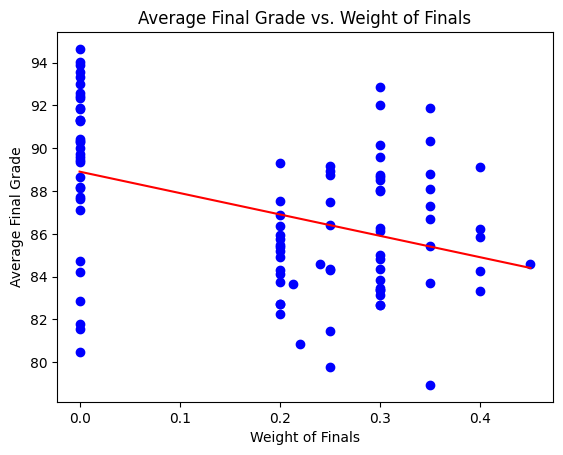

Slope: -10.003618807377395
Average Grade Change per Additional 1% Weight: -0.100%
Intercept: 88.90602265261182
R-squared: 0.1572112324391468


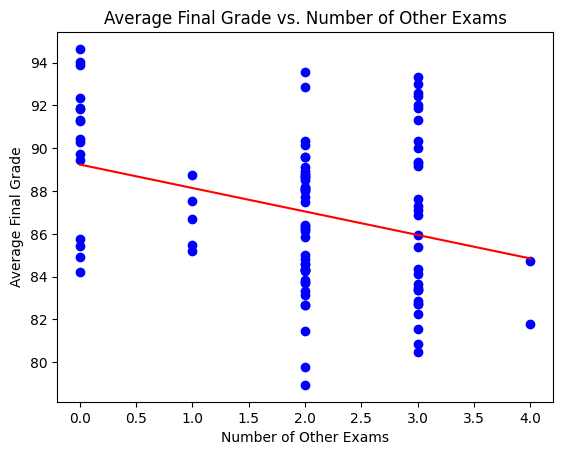

Slope: -1.0981682419659757
Average Grade Change per Additional Assignment: -1.098%
Intercept: 89.24025141776939
R-squared: 0.1005447701348823


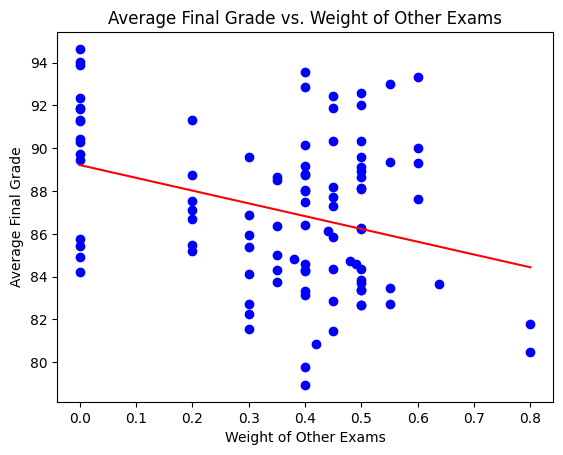

Slope: -5.977412857376442
Average Grade Change per Additional 1% Weight: -0.060%
Intercept: 89.21621285398344
R-squared: 0.09999178066542935


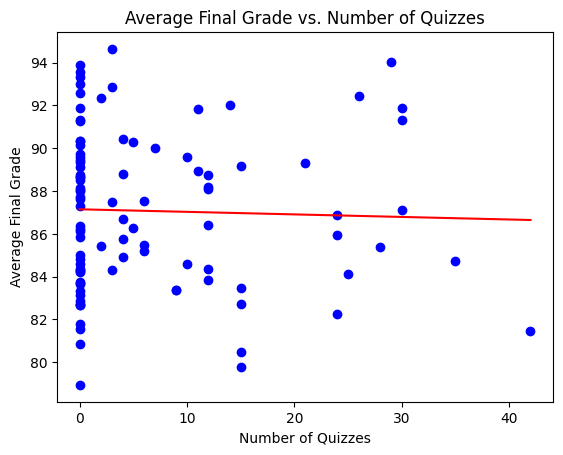

Slope: -0.011909746793931308
Average Grade Change per Additional Assignment: -0.012%
Intercept: 87.14653502942852
R-squared: 0.0010361368041251267


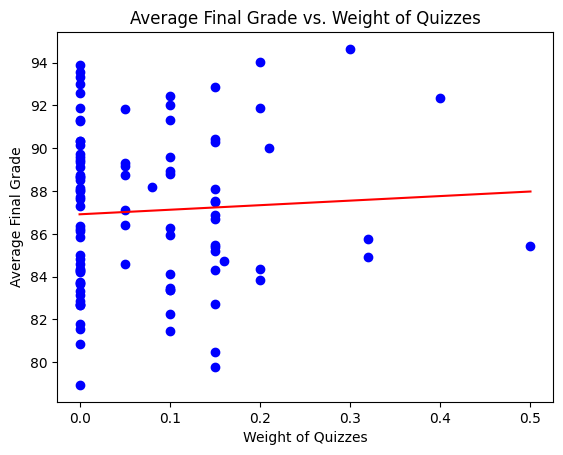

Slope: 2.130584709137966
Average Grade Change per Additional 1% Weight: 0.021%
Intercept: 86.9121852491042
R-squared: 0.003235509807390559


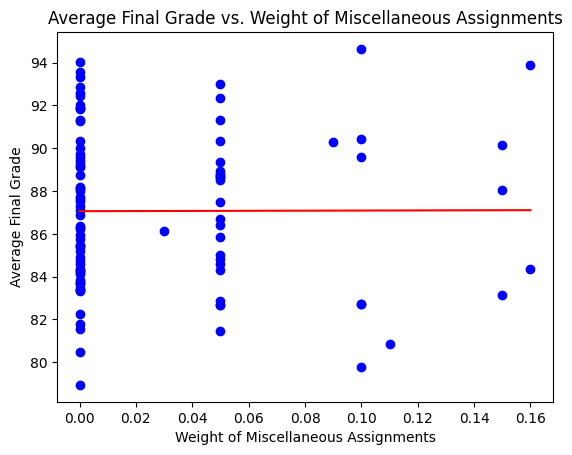

Slope: 0.3014575508839957
Average Grade Change per Additional 1% Weight: 0.003%
Intercept: 87.05786726260274
R-squared: 1.2641670068809995e-05


In [ ]:
# This code applies linear regression to each feature individually to see how it
# impacts the final grade on its own.

# Import data
X_data = pd.read_csv('Final Datasheet - XDataImport - AVERAGE GRADES.csv')
Y_data = pd.read_csv('Final Datasheet - YDataImport - AVERAGE GRADES.csv')

# Convert data to numpy array and remove last "TEST" row
X_data = pd.DataFrame.to_numpy(X_data)
Y_data = pd.DataFrame.to_numpy(Y_data)
X_data = X_data[0:len(X_data)-1]
Y_data = Y_data[0:len(Y_data)-1]

Y_data = Y_data.astype(float).flatten()
#print(Y_data)

Num_HWs = X_data[:,0].astype(float).flatten()
#print(Num_HWs)
Weight_HWs = X_data[:,1].astype(float).flatten()
#print(Weight_HWs)

Num_Projects = X_data[:,2].astype(float).flatten()
#print(Num_Projects)
Weight_Projects = X_data[:,3].astype(float).flatten()
#print(Weight_Projects)

Num_Finals = X_data[:,4].astype(float).flatten()
#print(Num_Finals)
Weight_Finals = X_data[:,5].astype(float).flatten()
#print(Weight_Finals)

Num_Exams = X_data[:,6].astype(float).flatten()
#print(Num_Exams)
Weight_Exams = X_data[:,7].astype(float).flatten()
#print(Weight_Exams)

Num_Quizzes = X_data[:,8].astype(float).flatten()
#print(Num_Quizzes)
Weight_Quizzes = X_data[:,9].astype(float).flatten()
#print(Weight_Quizzes)

Weight_Misc = X_data[:,10].astype(float).flatten()
#print(Weight_Misc)

#-------------------------------------------------------------------------------
# LINEAR REGRESSION
#-------------------------------------------------------------------------------

# Number of Homeworks
lin_model = LinearRegression()

# Train the model
Num_HWs_model = lin_model.fit(Num_HWs.reshape(-1,1), Y_data)
Num_HWs_sorted = np.sort(Num_HWs)
Num_HWs_predict = Num_HWs_model.predict(Num_HWs_sorted.reshape(-1,1))

# Plotting the data points with the fit line
plt.plot(Num_HWs_sorted, Num_HWs_predict, color='red')
plt.scatter(Num_HWs, Y_data, color='blue')

plt.xlabel('Number of Homeworks')
plt.ylabel('Average Final Grade')
plt.title('Average Final Grade vs. Number of Homeworks')
plt.show()

slope, intercept, r_value, p_value, std_err = linregress(Num_HWs, Y_data)
print("Slope:", slope)
print(f"Average Grade Change per Additional Assignment: {slope:.3f}%")
print("Intercept:", intercept)
print("R-squared:", r_value**2)

#------------------------------------------------------------------------------

# Weight of Homeworks
lin_model = LinearRegression()

# Train the model
Weight_HWs_model = lin_model.fit(Weight_HWs.reshape(-1,1), Y_data)
Weight_HWs_sorted = np.sort(Weight_HWs)
Weight_HWs_predict = Weight_HWs_model.predict(Weight_HWs_sorted.reshape(-1,1))

# Plotting the data points with the fit line
plt.plot(Weight_HWs_sorted, Weight_HWs_predict, color='red')
plt.scatter(Weight_HWs, Y_data, color='blue')

plt.xlabel('Weight of Homeworks')
plt.ylabel('Average Final Grade')
plt.title('Average Final Grade vs. Weight of Homeworks')
plt.show()

slope, intercept, r_value, p_value, std_err = linregress(Weight_HWs, Y_data)
print("Slope:", slope)
print(f"Average Grade Change per Additional 1% Weight: {slope/100:.3f}%")
print("Intercept:", intercept)
print("R-squared:", r_value**2)

#-------------------------------------------------------------------------------

# Number of Project Assignments
lin_model = LinearRegression()

# Train the model
Num_Projects_model = lin_model.fit(Num_Projects.reshape(-1,1), Y_data)
Num_Projects_sorted = np.sort(Num_Projects)
Num_Projects_predict = Num_Projects_model.predict(Num_Projects_sorted.reshape(-1,1))

# Plotting the data points with the fit line
plt.plot(Num_Projects_sorted, Num_Projects_predict, color='red')
plt.scatter(Num_Projects, Y_data, color='blue')

plt.xlabel('Number of Project Assignments')
plt.ylabel('Average Final Grade')
plt.title('Average Final Grade vs. Number of Project Assignments')
plt.show()

slope, intercept, r_value, p_value, std_err = linregress(Num_Projects, Y_data)
print("Slope:", slope)
print(f"Average Grade Change per Additional Assignment: {slope:.3f}%")
print("Intercept:", intercept)
print("R-squared:", r_value**2)

#-------------------------------------------------------------------------------

# Weight of Project Assignments
lin_model = LinearRegression()

# Train the model
Weight_Projects_model = lin_model.fit(Weight_Projects.reshape(-1,1), Y_data)
Weight_Projects_sorted = np.sort(Weight_Projects)
Weight_Projects_predict = Weight_Projects_model.predict(Weight_Projects_sorted.reshape(-1,1))

# Plotting the data points with the fit line
plt.plot(Weight_Projects_sorted, Weight_Projects_predict, color='red')
plt.scatter(Weight_Projects, Y_data, color='blue')

plt.xlabel('Weight of Project Assignments')
plt.ylabel('Average Final Grade')
plt.title('Average Final Grade vs. Weight of Project Assignments')
plt.show()

slope, intercept, r_value, p_value, std_err = linregress(Weight_Projects, Y_data)
print("Slope:", slope)
print(f"Average Grade Change per Additional 1% Weight: {slope/100:.3f}%")
print("Intercept:", intercept)
print("R-squared:", r_value**2)

#-------------------------------------------------------------------------------

# Number of Finals
lin_model = LinearRegression()

# Train the model
Num_Finals_model = lin_model.fit(Num_Finals.reshape(-1,1), Y_data)
Num_Finals_sorted = np.sort(Num_Finals)
Num_Finals_predict = Num_Finals_model.predict(Num_Finals_sorted.reshape(-1,1))

# Plotting the data points with the fit line
plt.plot(Num_Finals_sorted, Num_Finals_predict, color='red')
plt.scatter(Num_Finals, Y_data, color='blue')

plt.xlabel('Number of Finals')
plt.ylabel('Average Final Grade')
plt.title('Average Final Grade vs. Number of Finals')
plt.show()

slope, intercept, r_value, p_value, std_err = linregress(Num_Finals, Y_data)
print("Slope:", slope)
print(f"Average Grade Change per Additional Assignment: {slope:.3f}%")
print("Intercept:", intercept)
print("R-squared:", r_value**2)

#-------------------------------------------------------------------------------

# Weight of Finals
lin_model = LinearRegression()

# Train the model
Weight_Finals_model = lin_model.fit(Weight_Finals.reshape(-1,1), Y_data)
Weight_Finals_sorted = np.sort(Weight_Finals)
Weight_Finals_predict = Weight_Finals_model.predict(Weight_Finals_sorted.reshape(-1,1))

# Plotting the data points with the fit line
plt.plot(Weight_Finals_sorted, Weight_Finals_predict, color='red')
plt.scatter(Weight_Finals, Y_data, color='blue')

plt.xlabel('Weight of Finals')
plt.ylabel('Average Final Grade')
plt.title('Average Final Grade vs. Weight of Finals')
plt.show()

slope, intercept, r_value, p_value, std_err = linregress(Weight_Finals, Y_data)
print("Slope:", slope)
print(f"Average Grade Change per Additional 1% Weight: {slope/100:.3f}%")
print("Intercept:", intercept)
print("R-squared:", r_value**2)

#-------------------------------------------------------------------------------

# Number of Other Exams
lin_model = LinearRegression()

# Train the model
Num_Exams_model = lin_model.fit(Num_Exams.reshape(-1,1), Y_data)
Num_Exams_sorted = np.sort(Num_Exams)
Num_Exams_predict = Num_Exams_model.predict(Num_Exams_sorted.reshape(-1,1))

# Plotting the data points with the fit line
plt.plot(Num_Exams_sorted, Num_Exams_predict, color='red')
plt.scatter(Num_Exams, Y_data, color='blue')

plt.xlabel('Number of Other Exams')
plt.ylabel('Average Final Grade')
plt.title('Average Final Grade vs. Number of Other Exams')
plt.show()

slope, intercept, r_value, p_value, std_err = linregress(Num_Exams, Y_data)
print("Slope:", slope)
print(f"Average Grade Change per Additional Assignment: {slope:.3f}%")
print("Intercept:", intercept)
print("R-squared:", r_value**2)

#-------------------------------------------------------------------------------

# Weight of Other Exams
lin_model = LinearRegression()

# Train the model
Weight_Exams_model = lin_model.fit(Weight_Exams.reshape(-1,1), Y_data)
Weight_Exams_sorted = np.sort(Weight_Exams)
Weight_Exams_predict = Weight_Exams_model.predict(Weight_Exams_sorted.reshape(-1,1))

# Plotting the data points with the fit line
plt.plot(Weight_Exams_sorted, Weight_Exams_predict, color='red')
plt.scatter(Weight_Exams, Y_data, color='blue')

plt.xlabel('Weight of Other Exams')
plt.ylabel('Average Final Grade')
plt.title('Average Final Grade vs. Weight of Other Exams')
plt.show()

slope, intercept, r_value, p_value, std_err = linregress(Weight_Exams, Y_data)
print("Slope:", slope)
print(f"Average Grade Change per Additional 1% Weight: {slope/100:.3f}%")
print("Intercept:", intercept)
print("R-squared:", r_value**2)

#-------------------------------------------------------------------------------

# Number of Quizzes
lin_model = LinearRegression()

# Train the model
Num_Quizzes_model = lin_model.fit(Num_Quizzes.reshape(-1,1), Y_data)
Num_Quizzes_sorted = np.sort(Num_Quizzes)
Num_Quizzes_predict = Num_Quizzes_model.predict(Num_Quizzes_sorted.reshape(-1,1))

# Plotting the data points with the fit line
plt.plot(Num_Quizzes_sorted, Num_Quizzes_predict, color='red')
plt.scatter(Num_Quizzes, Y_data, color='blue')

plt.xlabel('Number of Quizzes')
plt.ylabel('Average Final Grade')
plt.title('Average Final Grade vs. Number of Quizzes')
plt.show()

slope, intercept, r_value, p_value, std_err = linregress(Num_Quizzes, Y_data)
print("Slope:", slope)
print(f"Average Grade Change per Additional Assignment: {slope:.3f}%")
print("Intercept:", intercept)
print("R-squared:", r_value**2)

#-------------------------------------------------------------------------------

# Weight of Quizzes
lin_model = LinearRegression()

# Train the model
Weight_Quizzes_model = lin_model.fit(Weight_Quizzes.reshape(-1,1), Y_data)
Weight_Quizzes_sorted = np.sort(Weight_Quizzes)
Weight_Quizzes_predict = Weight_Quizzes_model.predict(Weight_Quizzes_sorted.reshape(-1,1))

# Plotting the data points with the fit line
plt.plot(Weight_Quizzes_sorted, Weight_Quizzes_predict, color='red')
plt.scatter(Weight_Quizzes, Y_data, color='blue')

plt.xlabel('Weight of Quizzes')
plt.ylabel('Average Final Grade')
plt.title('Average Final Grade vs. Weight of Quizzes')
plt.show()

slope, intercept, r_value, p_value, std_err = linregress(Weight_Quizzes, Y_data)
print("Slope:", slope)
print(f"Average Grade Change per Additional 1% Weight: {slope/100:.3f}%")
print("Intercept:", intercept)
print("R-squared:", r_value**2)

#-------------------------------------------------------------------------------

# Weight of Miscellaneous Assignments
lin_model = LinearRegression()

# Train the model
Weight_Misc_model = lin_model.fit(Weight_Misc.reshape(-1,1), Y_data)
Weight_Misc_sorted = np.sort(Weight_Misc)
Weight_Misc_predict = Weight_Misc_model.predict(Weight_Misc_sorted.reshape(-1,1))

# Plotting the data points with the fit line
plt.plot(Weight_Misc_sorted, Weight_Misc_predict, color='red')
plt.scatter(Weight_Misc, Y_data, color='blue')

plt.xlabel('Weight of Miscellaneous Assignments')
plt.ylabel('Average Final Grade')
plt.title('Average Final Grade vs. Weight of Miscellaneous Assignments')
plt.show()

slope, intercept, r_value, p_value, std_err = linregress(Weight_Misc, Y_data)
print("Slope:", slope)
print(f"Average Grade Change per Additional 1% Weight: {slope/100:.3f}%")
print("Intercept:", intercept)
print("R-squared:", r_value**2)

# REGRESSION MODELS FUNCTION DEFINITION - OPTIMIZING TO R2 SCORE

In [ ]:
"""
REGRESSION FUNCTION DEFINITION - MUST RUN BEFORE CALLING REGRESSION CODE BLOCKS
"""
def run_regression_models_r2(X_data, Y_data, print_outputs = False, show_error = True, data_is_pandas = True, y_max = 100, seed = 42, seed_eval = False, run_lin = False, run_ridge = False, run_lasso = False, run_enet = False, run_dec_tree = False, run_rf = False, run_knn = False, run_all = True):
  if data_is_pandas:
    # Convert data to numpy array and remove last "TEST" row
    X_data = pd.DataFrame.to_numpy(X_data)
    Y_data = pd.DataFrame.to_numpy(Y_data)
    X_data = X_data[0:len(X_data)-1]
    Y_data = Y_data[0:len(Y_data)-1]
  X_data = X_data.astype(np.float64)
  Y_data = Y_data.astype(np.float64)

  # Reshape Y_data to be 2D
  Y_data = Y_data.reshape(-1, 1) # Reshape to 2D ######

  if run_all:
    run_lin = True
    run_ridge = True
    run_lasso = True
    run_enet = True
    run_dec_tree = True
    run_rf = True
    run_knn = True

  mae_dict = {}
  # Create train and test data
  X_train, X_test, Y_train, Y_test = train_test_split(X_data, Y_data, test_size=0.2, random_state = seed)

  #print(X_train)
  #print(Y_train)

  # SCALE THE DATA:
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)
  Y_train_scaled = scaler.fit_transform(Y_train)
  Y_test_scaled = scaler.transform(Y_test)

  random_index = random.randint(0, 19)
  best_mae = 1000000000000000

  # -----------------------------------------------------------------------------------------------------
  # LINEAR REGRESSION:
  if run_lin:
    # Create model
    lin_model = LinearRegression()

    # Train model:
    lin_model.fit(X_train_scaled, Y_train_scaled)

    # Predict distribution
    Y_pred_scaled = lin_model.predict(X_test_scaled)

    # Inverse scale predictions
    Y_pred = scaler.inverse_transform(Y_pred_scaled.reshape(-1,1)) ######

    Y_pred = np.maximum(0, Y_pred)

    if mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average') < best_mae:
      best_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')
      best_Y_pred = Y_pred

    mae_dict.update({(mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')): "Linear Regression"})
    lin_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')

    if print_outputs:
      print(Y_pred)
      print(Y_test)
    if show_error:
      print(f"LINEAR REGRESSION RESULTS:")
      print(f"Mean Squared Error: {mean_squared_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Mean Absolute Error: {mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Custom Error: {custom_error(Y_test, Y_pred)}")
      print(f"R2 Score: {r2_score(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"---------------------------")

      # Code for plotting after Y_pred is calculated and scaled.

      # Randomly sample 10 indices
      indices = np.random.choice(range(len(Y_test)), size=10, replace=False)

      # Extract predicted and true values for the selected indices
      y_pred_sample = Y_pred[indices].flatten()
      y_true_sample = Y_test[indices].flatten()

      # Create bar plot
      plt.figure(figsize=(10, 6))
      bar_width = 0.4
      x = np.arange(10)  # Ten random data points

      # Predicted and true bar plots
      plt.bar(x - bar_width/2, y_true_sample, bar_width, label='True Values', color='blue')
      plt.bar(x + bar_width/2, y_pred_sample, bar_width, label='Predicted Values', color='orange')

      # Add labels, title, and legend
      plt.xlabel('Random Student Number')
      plt.ylabel('Percentage Grade')
      plt.title(f'{mae_dict[mean_absolute_error(Y_test, Y_pred, multioutput="uniform_average")]}: Predicted vs True Values')
      plt.xticks(x)
      plt.legend()
      plt.tight_layout()

      # Show the plot
      plt.show()

  # -----------------------------------------------------------------------------------------------------
  # RIDGE REGRESSION:
  if run_ridge:
    pipeline = Pipeline([
        ('poly', PolynomialFeatures()),
        ('ridge', Ridge())
    ])

    params = {
        'poly__degree': [1, 2, 3],
        'ridge__alpha': np.logspace(-3, 3, 10),
        'ridge__solver': ['auto']
    }
    ridge_regressor = GridSearchCV(pipeline, params, scoring='r2', cv=5, n_jobs=-1)
    ridge_regressor.fit(X_train_scaled, Y_train_scaled)
    Y_pred_scaled = ridge_regressor.predict(X_test_scaled)
    Y_pred = scaler.inverse_transform(Y_pred_scaled.reshape(-1,1)) ######

    Y_pred = np.maximum(0, Y_pred)

    if mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average') < best_mae:
      best_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')
      best_Y_pred = Y_pred

    mae_dict.update({(mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')): "Ridge Regression"})
    ridge_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')

    if print_outputs:
      print(Y_pred)
      print(Y_test)
    if show_error:
      print(f"RIDGE REGRESSION RESULTS:")
      print(f"Mean Squared Error: {mean_squared_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Mean Absolute Error: {mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Custom Error: {custom_error(Y_test, Y_pred)}")
      print(f"R2 score: {r2_score(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"---------------------------")

      # Code for plotting after Y_pred is calculated and scaled.

      # Randomly sample 10 indices
      indices = np.random.choice(range(len(Y_test)), size=10, replace=False)

      # Extract predicted and true values for the selected indices
      y_pred_sample = Y_pred[indices].flatten()
      y_true_sample = Y_test[indices].flatten()

      # Create bar plot
      plt.figure(figsize=(10, 6))
      bar_width = 0.4
      x = np.arange(10)  # Ten random data points

      # Predicted and true bar plots
      plt.bar(x - bar_width/2, y_true_sample, bar_width, label='True Values', color='blue')
      plt.bar(x + bar_width/2, y_pred_sample, bar_width, label='Predicted Values', color='orange')

      # Add labels, title, and legend
      plt.xlabel('Random Student Number')
      plt.ylabel('Percentage Grade')
      plt.title(f'{mae_dict[mean_absolute_error(Y_test, Y_pred, multioutput="uniform_average")]}: Predicted vs True Values')
      plt.xticks(x)
      plt.legend()
      plt.tight_layout()

      # Show the plot
      plt.show()
  # -----------------------------------------------------------------------------------------------------
  # LASSO REGRESSION:
  if run_lasso:
    params = {
        'alpha': np.logspace(-3, 3, 10)
    }
    lasso_regressor = GridSearchCV(Lasso(max_iter=10000), params, scoring='r2', cv=5)
    lasso_regressor.fit(X_train_scaled, Y_train_scaled)
    Y_pred_scaled = lasso_regressor.predict(X_test_scaled)
    Y_pred = scaler.inverse_transform(Y_pred_scaled.reshape(-1,1)) ######

    Y_pred = np.maximum(0, Y_pred)

    if mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average') < best_mae:
      best_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')
      best_Y_pred = Y_pred

    mae_dict.update({(mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')): "Lasso Regression"})
    lasso_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')

    if print_outputs:
      print(Y_pred)
      print(Y_test)
    if show_error:
      print(f"LASSO REGRESSION RESULTS:")
      print(f"Mean Squared Error: {mean_squared_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Mean Absolute Error: {mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Custom Error: {custom_error(Y_test, Y_pred)}")
      print(f"R2 score: {r2_score(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"---------------------------")

     # Code for plotting after Y_pred is calculated and scaled.

      # Randomly sample 10 indices
      indices = np.random.choice(range(len(Y_test)), size=10, replace=False)

      # Extract predicted and true values for the selected indices
      y_pred_sample = Y_pred[indices].flatten()
      y_true_sample = Y_test[indices].flatten()

      # Create bar plot
      plt.figure(figsize=(10, 6))
      bar_width = 0.4
      x = np.arange(10)  # Ten random data points

      # Predicted and true bar plots
      plt.bar(x - bar_width/2, y_true_sample, bar_width, label='True Values', color='blue')
      plt.bar(x + bar_width/2, y_pred_sample, bar_width, label='Predicted Values', color='orange')

      # Add labels, title, and legend
      plt.xlabel('Random Student Number')
      plt.ylabel('Percentage Grade')
      plt.title(f'{mae_dict[mean_absolute_error(Y_test, Y_pred, multioutput="uniform_average")]}: Predicted vs True Values')
      plt.xticks(x)
      plt.legend()
      plt.tight_layout()

      # Show the plot
      plt.show()
  # -----------------------------------------------------------------------------------------------------
  # ELASTIC NET REGRESSION:
  if run_enet:
    params = {
        'alpha': np.logspace(-3, 3, 10),
        'l1_ratio': np.linspace(0.1, 0.9, 10)
    }
    elastic_net_regressor = GridSearchCV(ElasticNet(max_iter=50000), params, scoring='r2', cv=5)
    elastic_net_regressor.fit(X_train_scaled, Y_train_scaled)
    Y_pred_scaled = elastic_net_regressor.predict(X_test_scaled)
    Y_pred = scaler.inverse_transform(Y_pred_scaled.reshape(-1,1)) ######

    Y_pred = np.maximum(0, Y_pred)

    if mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average') < best_mae:
      best_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')
      best_Y_pred = Y_pred

    mae_dict.update({(mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')): "Elastic Net Regression"})
    enet_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')

    if print_outputs:
      print(Y_pred)
      print(Y_test)
    if show_error:
      print(f"ELASTIC NET REGRESSION RESULTS:")
      print(f"Mean Squared Error: {mean_squared_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Mean Absolute Error: {mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Custom Error: {custom_error(Y_test, Y_pred)}")
      print(f"R2 score: {r2_score(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"---------------------------")

     # Code for plotting after Y_pred is calculated and scaled.

      # Randomly sample 10 indices
      indices = np.random.choice(range(len(Y_test)), size=10, replace=False)

      # Extract predicted and true values for the selected indices
      y_pred_sample = Y_pred[indices].flatten()
      y_true_sample = Y_test[indices].flatten()

      # Create bar plot
      plt.figure(figsize=(10, 6))
      bar_width = 0.4
      x = np.arange(10)  # Ten random data points

      # Predicted and true bar plots
      plt.bar(x - bar_width/2, y_true_sample, bar_width, label='True Values', color='blue')
      plt.bar(x + bar_width/2, y_pred_sample, bar_width, label='Predicted Values', color='orange')

      # Add labels, title, and legend
      plt.xlabel('Random Student Number')
      plt.ylabel('Percentage Grade')
      plt.title(f'{mae_dict[mean_absolute_error(Y_test, Y_pred, multioutput="uniform_average")]}: Predicted vs True Values')
      plt.xticks(x)
      plt.legend()
      plt.tight_layout()

      # Show the plot
      plt.show()
  # -----------------------------------------------------------------------------------------------------
  # DECISION TREE REGRESSION:
  if run_dec_tree:
    params = {
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'ccp_alpha': np.logspace(-3, 3, 10)
    }

    dect_tree_regressor = GridSearchCV(DecisionTreeRegressor(random_state=42), params, scoring='r2', cv=5)
    dect_tree_regressor.fit(X_train_scaled, Y_train_scaled)
    Y_pred_scaled = dect_tree_regressor.predict(X_test_scaled)
    Y_pred = scaler.inverse_transform(Y_pred_scaled.reshape(-1,1)) ######

    Y_pred = np.maximum(0, Y_pred)

    if mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average') < best_mae:
      best_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')
      best_Y_pred = Y_pred

    mae_dict.update({(mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')): "Decision Tree Regression"})
    dec_tree_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')

    if print_outputs:
      print(Y_pred)
      print(Y_test)
    if show_error:
      print(f"DECISION TREE REGRESSION RESULTS:")
      print(f"Mean Squared Error: {mean_squared_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Mean Absolute Error: {mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Custom Error: {custom_error(Y_test, Y_pred)}")
      print(f"R2 score: {r2_score(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"---------------------------")

     # Code for plotting after Y_pred is calculated and scaled.

      # Randomly sample 10 indices
      indices = np.random.choice(range(len(Y_test)), size=10, replace=False)

      # Extract predicted and true values for the selected indices
      y_pred_sample = Y_pred[indices].flatten()
      y_true_sample = Y_test[indices].flatten()

      # Create bar plot
      plt.figure(figsize=(10, 6))
      bar_width = 0.4
      x = np.arange(10)  # Ten random data points

      # Predicted and true bar plots
      plt.bar(x - bar_width/2, y_true_sample, bar_width, label='True Values', color='blue')
      plt.bar(x + bar_width/2, y_pred_sample, bar_width, label='Predicted Values', color='orange')

      # Add labels, title, and legend
      plt.xlabel('Random Student Number')
      plt.ylabel('Percentage Grade')
      plt.title(f'{mae_dict[mean_absolute_error(Y_test, Y_pred, multioutput="uniform_average")]}: Predicted vs True Values')
      plt.xticks(x)
      plt.legend()
      plt.tight_layout()

      # Show the plot
      plt.show()
  # -----------------------------------------------------------------------------------------------------
  # RANDOM FOREST REGRESSION:
  if run_rf:
    params = {
        'n_estimators': [50, 100],
        'max_depth': [None, 10, 20],
        'min_samples_split': [5, 10],
        'min_samples_leaf': [1, 2]
    }
    rf_regressor = GridSearchCV(RandomForestRegressor(random_state=42), params, scoring='r2', cv=5)
    rf_regressor.fit(X_train_scaled, Y_train_scaled)
    Y_pred_scaled = rf_regressor.predict(X_test_scaled)
    Y_pred = scaler.inverse_transform(Y_pred_scaled.reshape(-1,1)) ######

    Y_pred = np.maximum(0, Y_pred)

    if mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average') < best_mae:
      best_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')
      best_Y_pred = Y_pred

    mae_dict.update({(mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')): "Random Forest Regression"})
    rf_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')

    if print_outputs:
      print(Y_pred)
      print(Y_test)
    if show_error:
      print(f"RANDOM FOREST REGRESSION RESULTS:")
      print(f"Mean Squared Error: {mean_squared_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Mean Absolute Error: {mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Custom Error: {custom_error(Y_test, Y_pred)}")
      print(f"R2 score: {r2_score(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"---------------------------")

     # Code for plotting after Y_pred is calculated and scaled.

      # Randomly sample 10 indices
      indices = np.random.choice(range(len(Y_test)), size=10, replace=False)

      # Extract predicted and true values for the selected indices
      y_pred_sample = Y_pred[indices].flatten()
      y_true_sample = Y_test[indices].flatten()

      # Create bar plot
      plt.figure(figsize=(10, 6))
      bar_width = 0.4
      x = np.arange(10)  # Ten random data points

      # Predicted and true bar plots
      plt.bar(x - bar_width/2, y_true_sample, bar_width, label='True Values', color='blue')
      plt.bar(x + bar_width/2, y_pred_sample, bar_width, label='Predicted Values', color='orange')

      # Add labels, title, and legend
      plt.xlabel('Random Student Number')
      plt.ylabel('Percentage Grade')
      plt.title(f'{mae_dict[mean_absolute_error(Y_test, Y_pred, multioutput="uniform_average")]}: Predicted vs True Values')
      plt.xticks(x)
      plt.legend()
      plt.tight_layout()

      # Show the plot
      plt.show()
  # -----------------------------------------------------------------------------------------------------
  # KNEIGHBORS REGRESSION:
  if run_knn:
    params_knn = {
        'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    }
    knn_regressor = GridSearchCV(KNeighborsRegressor(), params_knn, scoring='r2', cv=5, n_jobs=-1)
    knn_regressor.fit(X_train_scaled, Y_train_scaled)
    Y_pred_scaled = knn_regressor.predict(X_test_scaled)
    Y_pred = scaler.inverse_transform(Y_pred_scaled.reshape(-1,1)) ######

    if mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average') < best_mae:
      best_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')
      best_Y_pred = Y_pred

    mae_dict.update({(mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')): "KNeighbors Regression"})
    knn_mae = mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')

    if print_outputs:
      print(Y_pred)
      print(Y_test)
    if show_error:
      print(f"KNEIGHBORS REGRESSION RESULTS:")
      print(f"Mean Squared Error: {mean_squared_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Mean Absolute Error: {mean_absolute_error(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"Custom Error: {custom_error(Y_test, Y_pred)}")
      print(f"R2 Score: {r2_score(Y_test, Y_pred, multioutput='uniform_average')}")
      print(f"---------------------------")

     # Code for plotting after Y_pred is calculated and scaled.

      # Randomly sample 10 indices
      indices = np.random.choice(range(len(Y_test)), size=10, replace=False)

      # Extract predicted and true values for the selected indices
      y_pred_sample = Y_pred[indices].flatten()
      y_true_sample = Y_test[indices].flatten()

      # Create bar plot
      plt.figure(figsize=(10, 6))
      bar_width = 0.4
      x = np.arange(10)  # Ten random data points

      # Predicted and true bar plots
      plt.bar(x - bar_width/2, y_true_sample, bar_width, label='True Values', color='blue')
      plt.bar(x + bar_width/2, y_pred_sample, bar_width, label='Predicted Values', color='orange')

      # Add labels, title, and legend
      plt.xlabel('Random Student Number')
      plt.ylabel('Percentage Grade')
      plt.title(f'{mae_dict[mean_absolute_error(Y_test, Y_pred, multioutput="uniform_average")]}: Predicted vs True Values')
      plt.xticks(x)
      plt.legend()
      plt.tight_layout()

      # Show the plot
      plt.show()

  if(seed_eval):
    return lin_mae, ridge_mae, lasso_mae, enet_mae, dec_tree_mae, rf_mae, knn_mae, mae_dict
  else:
    return mae_dict

# STUDENT GRADE PREDICTION MODELS

MODEL 1: PREDICTING FINAL GRADE
LINEAR REGRESSION RESULTS:
Mean Squared Error: 121.93556489385806
Mean Absolute Error: 8.37615649146526
Custom Error: 0.12936936936936938
R2 Score: 0.4053434064118825
---------------------------


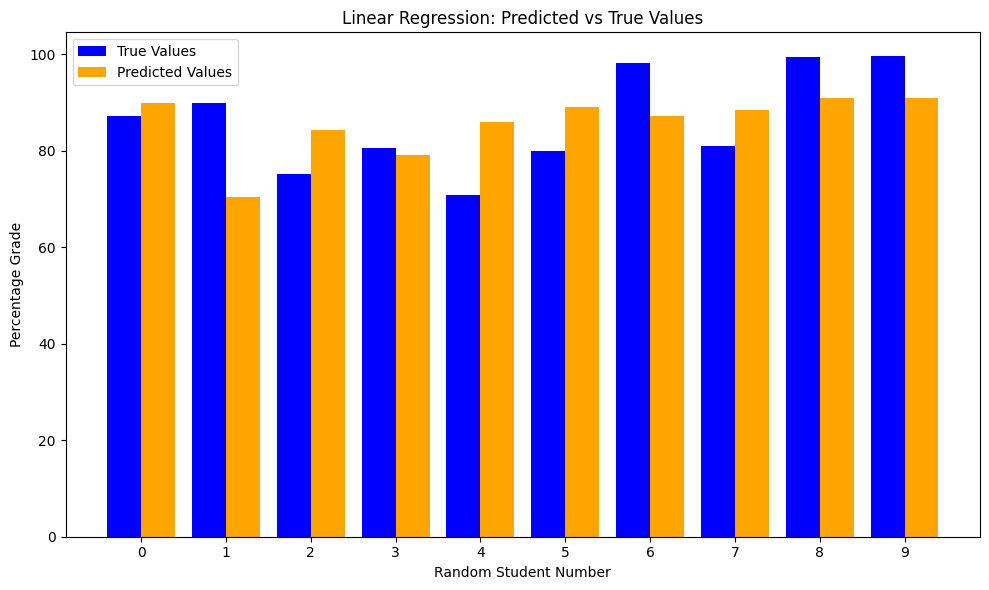

RIDGE REGRESSION RESULTS:
Mean Squared Error: 122.04229860500197
Mean Absolute Error: 8.381669361439112
Custom Error: 0.12972972972972974
R2 score: 0.4048228863720966
---------------------------


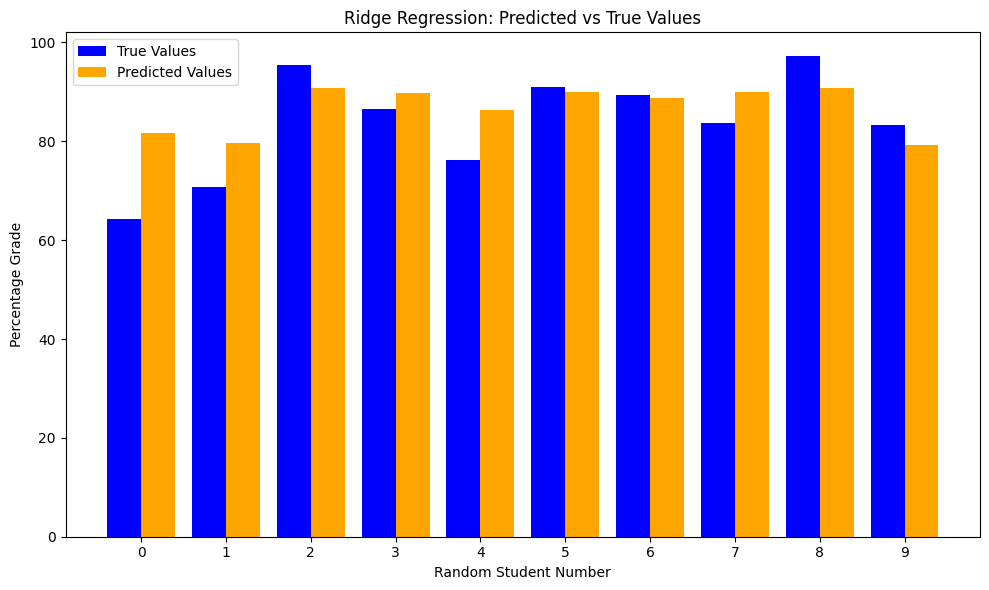

LASSO REGRESSION RESULTS:
Mean Squared Error: 121.9586047827499
Mean Absolute Error: 8.377291338121225
Custom Error: 0.12936936936936938
R2 score: 0.40523104524918974
---------------------------


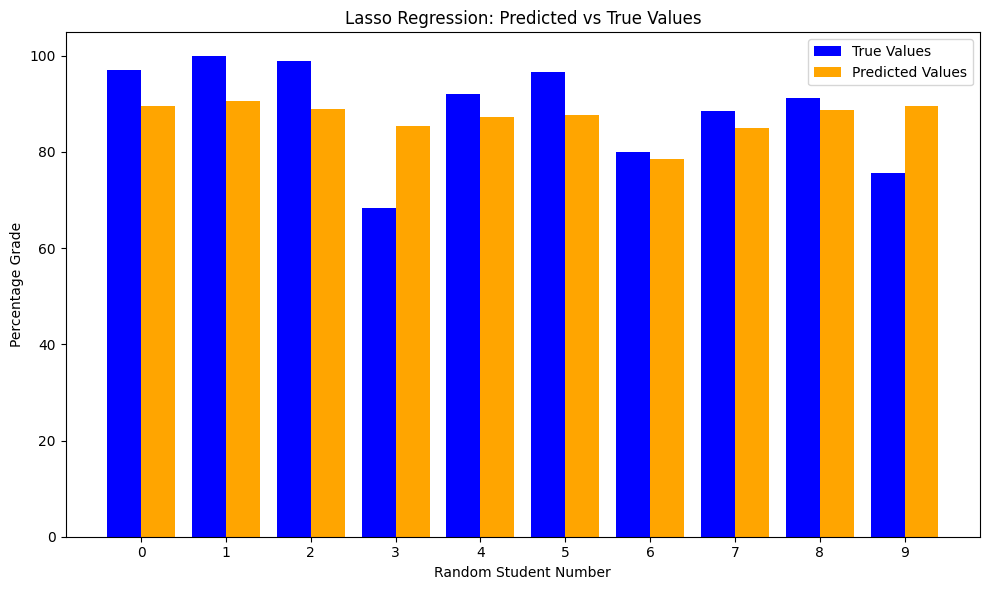

ELASTIC NET REGRESSION RESULTS:
Mean Squared Error: 122.09064826884008
Mean Absolute Error: 8.383681870347266
Custom Error: 0.12972972972972974
R2 score: 0.4045870942434906
---------------------------


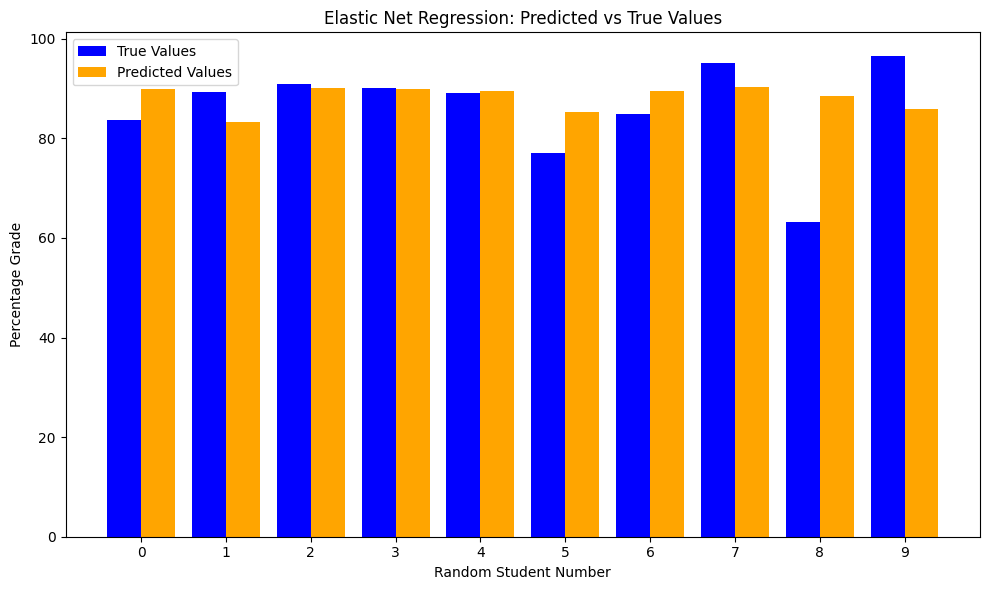

DECISION TREE REGRESSION RESULTS:
Mean Squared Error: 124.82235557434274
Mean Absolute Error: 8.391418078599655
Custom Error: 0.12576576576576576
R2 score: 0.39126507648448805
---------------------------


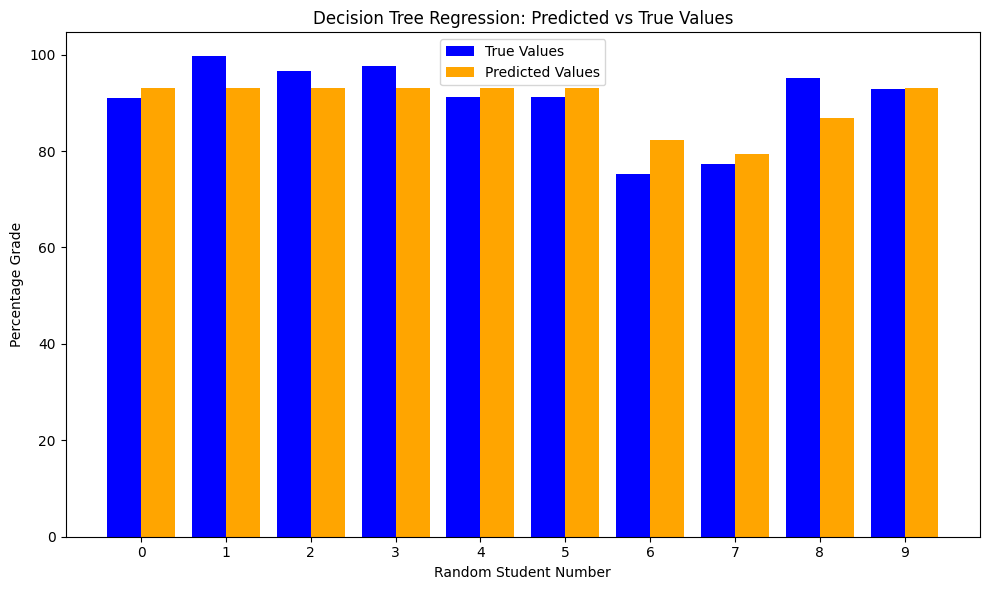

RANDOM FOREST REGRESSION RESULTS:
Mean Squared Error: 117.30067774961975
Mean Absolute Error: 7.980175698878269
Custom Error: 0.11171171171171171
R2 score: 0.4279468708175076
---------------------------


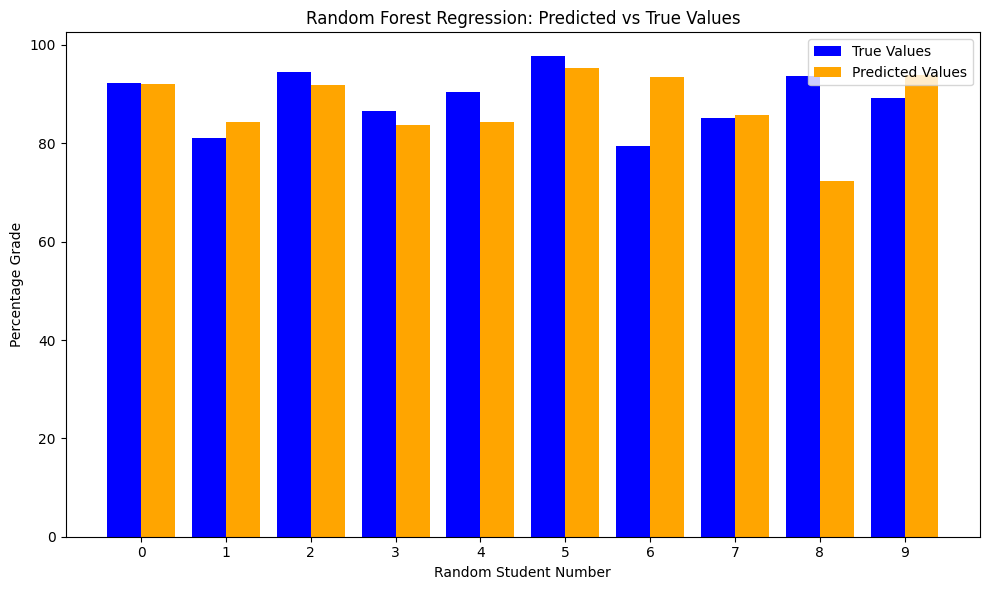

KNEIGHBORS REGRESSION RESULTS:
Mean Squared Error: 129.1741061959919
Mean Absolute Error: 8.475063063063063
Custom Error: 0.11567567567567567
R2 Score: 0.3700424151299646
---------------------------


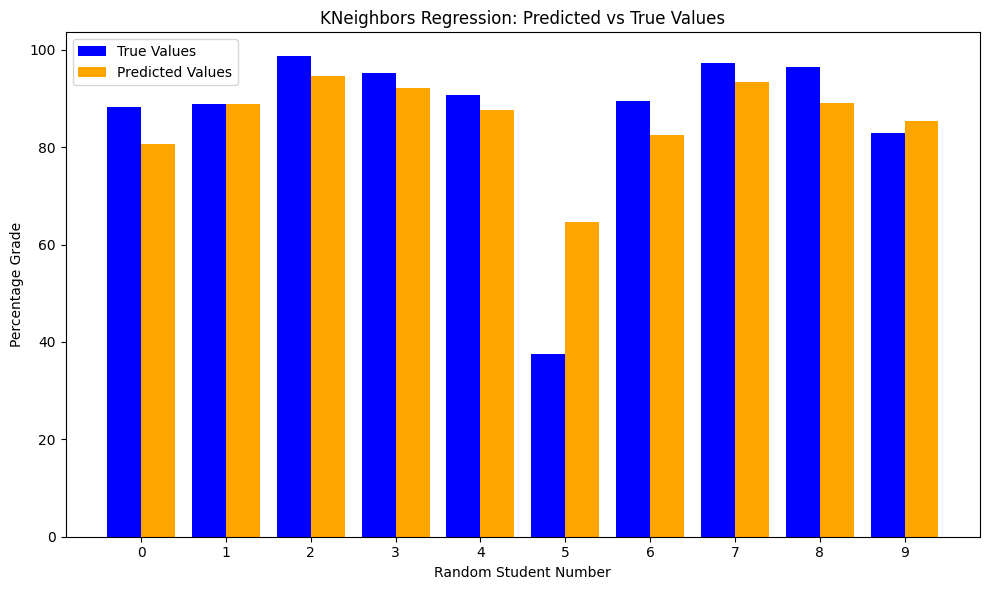

#######################################################################


In [ ]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")
# -----------------------------------------------------------------------------------------------------
# MODEL 1: PREDICTING FINAL GRADE
X_data = pd.read_csv('Final Datasheet UD only - XDataImport - STUDENT PREDICTION.csv')
Y_data = pd.read_csv('Final Datasheet UD only - YDataImport - FINAL GRADE.csv')

print("MODEL 1: PREDICTING FINAL GRADE")
#best_mae_model, best_mae_avg, seed_arr = evaluate_consistancy(X_data, Y_data)
r2_avg = run_regression_models_r2(X_data, Y_data)
#print(f'Best & Most Consistent Model w/ Average MAE Score Across {len(seed_arr)} Random Seeds: {best_mae_model}: {best_mae_avg}')

print("#######################################################################")